In [2]:
import numpy as np
import numba as nb
import math
from time import perf_counter
import matplotlib.pyplot as plt
import time

from gridcp import (
    OnlineChangepointDetector,
    make_univariate_mean_change_detector,
    make_univariate_variance_change_detector,
    make_univariate_mean_or_variance_change_detector,
    make_multivariate_mean_change_detector,
    make_multivariate_mean_or_covariance_change_detector,
    make_regression_change_detector,
)
from gridcp.utils import fastlog
from gridcp.calibration import draw_samples, mc_max_statistics
from gridcp import builtins
from gridcp.builtins import gen_gaussian_regression_obs

# General LR/GLR implementation for exponential families

**Primary goal:** Implement a **general** LR/GLR changepoint detector for exponential families.

For a canonical exponential family $p(y|\theta)=\eta(y)\exp(\theta^\top h(y)-A(\theta))$, the GLR
statistic is
$$f_b^{(t)} = \ell(\hat\theta_{1:b})+\ell(\hat\theta_{b+1:t})-\ell(\hat\theta_{1:t}),$$
where $\hat\theta$ are the MLEs, determined by $A$ and $h$ through solving the score equation
$\nabla A(\hat\theta) = \bar{h}$. The penalty scales as $v(\log t + \sqrt{\log t})$, where $v$
is the dimension of the sufficient statistic $h$. Hence, the test is fully determined as long as the user provides the following:
- `h` — sufficient statistic
- `A` — log-partition function
- `A_prime` — gradient of $A$ (optional, faster)
- `A_dprime` — Hessian of $A$ (optional, fastest — enables Newton's method)

Providing more derivatives enables faster and more Numba-compatible solvers, but the detector
should be correct regardless of which are provided.

## 1. Scalar newton implementation

In [3]:
# -----------------------------------------------------------
# 1. Scalar Newton MLE
# -----------------------------------------------------------

@nb.njit
def scalar_newton_mle(S_scalar, n, theta_init, A_prime, A_dprime, tol=1e-8, max_iter=20):
    """
    Scalar Newton solver for MLE in exponential families.
    Solves A'(theta) = S/n, where S = sum of sufficient statistics.
    
    Parameters
    ----------
    S_scalar : float
        Sum of sufficient statistics.
    n : int
        Number of observations.
    theta_init : float
        Initial guess for theta.
    A_prime : callable
        First derivative of log-partition function A.
    A_dprime : callable
        Second derivative of log-partition function A.
    tol : float
        Convergence tolerance.
    max_iter : int
        Maximum number of iterations.
    """
    theta = theta_init
    target = S_scalar / n
    for _ in range(max_iter):
        ap = A_prime(theta)
        residual = ap - target
        if abs(residual) < tol:
            return theta
        adp = A_dprime(theta)
        if adp < 1e-15:
            return theta
        theta = theta - residual / adp
    return theta


def make_newton_solver(A_prime, A_dprime):
    @nb.njit
    def solver(S, n, theta_init, tol=1e-8, max_iter=20):
        theta = theta_init
        target = S / n
        for _ in range(max_iter):
            residual = A_prime(theta) - target
            if abs(residual) < tol:
                return theta
            adp = A_dprime(theta)
            if adp < 1e-15:
                return theta
            theta -= residual / adp
        return theta
    return solver


# -----------------------------------------------------------
# Test case 1: Gaussian with known variance sigma^2 = 1
#
# For N(mu, 1), the canonical parameterization is:
#   theta = mu
#   h(x)  = x
#   A(theta) = theta^2 / 2
#   A'(theta) = theta       <-- MLE condition: theta_hat = x_bar
#   A''(theta) = 1
#
# So the MLE is just theta_hat = x_bar, which we can verify exactly.
# Newton converges in a single iteration since A'' is constant.
# -----------------------------------------------------------

@nb.njit
def A_prime_gaussian(theta):
    return theta

@nb.njit
def A_dprime_gaussian(theta):
    return 1.0

def A_prime_gaussian_py(theta):
    return theta

def A_dprime_gaussian_py(theta):
    return 1.0

# Generate data
np.random.seed(42)
n = 1000
mu_true = 2.5
X = np.random.normal(mu_true, 1.0, n)
S = np.sum(X)
x_bar = S / n  # true MLE

N_REPS = 100_000

# Callback Numba - warm-up + timing
_ = scalar_newton_mle(S, n, 0.0, A_prime_gaussian, A_dprime_gaussian)
start = time.perf_counter()
for _ in range(N_REPS):
    theta_hat = scalar_newton_mle(S, n, 0.0, A_prime_gaussian, A_dprime_gaussian)
elapsed_callback = time.perf_counter() - start

# Closure Numba - build + warm-up + timing
gaussian_solver = make_newton_solver(A_prime_gaussian, A_dprime_gaussian)
_ = gaussian_solver(S, n, 0.0)
start = time.perf_counter()
for _ in range(N_REPS):
    theta_hat_closure = gaussian_solver(S, n, 0.0)
elapsed_closure = time.perf_counter() - start

# Plain Python - warm-up + timing
def scalar_newton_mle_python(S_scalar, n, theta_init, A_prime, A_dprime, tol=1e-8, max_iter=20):
    theta = theta_init
    target = S_scalar / n
    for _ in range(max_iter):
        ap = A_prime(theta)
        residual = ap - target
        if abs(residual) < tol:
            return theta
        adp = A_dprime(theta)
        if adp < 1e-15:
            return theta
        theta = theta - residual / adp
    return theta

start = time.perf_counter()
for _ in range(N_REPS):
    theta_hat_py = scalar_newton_mle_python(S, n, 0.0, A_prime_gaussian_py, A_dprime_gaussian_py)
elapsed_python = time.perf_counter() - start

print("Gaussian (known variance)")
print(f"  True mean:              {mu_true:.6f}")
print(f"  Sample mean:            {x_bar:.6f}")
print(f"  Newton MLE (closure):   {theta_hat_closure:.6f}")
print(f"  Error:                  {abs(theta_hat_closure - x_bar):.2e}")
print(f"  Runtime (callback Numba): {elapsed_callback / N_REPS * 1e6:.3f} µs")
print(f"  Runtime (closure Numba):  {elapsed_closure  / N_REPS * 1e6:.3f} µs")
print(f"  Runtime (Python):         {elapsed_python   / N_REPS * 1e6:.3f} µs")
print(f"  Speedup vs callback Numba: {elapsed_callback / elapsed_closure:.1f}x")
print(f"  Speedup vs Python:         {elapsed_python   / elapsed_closure:.1f}x")

# -----------------------------------------------------------
# Test case 2: Poisson
#
# For Poisson(lambda), the canonical parameterization is:
#   theta  = log(lambda)
#   h(x)   = x
#   A(theta) = exp(theta)
#   A'(theta) = exp(theta)    <-- MLE condition: exp(theta_hat) = x_bar
#   A''(theta) = exp(theta)       i.e. theta_hat = log(x_bar)
# -----------------------------------------------------------

@nb.njit
def A_prime_poisson(theta):
    return np.exp(theta)

@nb.njit
def A_dprime_poisson(theta):
    return np.exp(theta)

def A_prime_poisson_py(theta):
    import math
    return math.exp(theta)

def A_dprime_poisson_py(theta):
    import math
    return math.exp(theta)

# Generate data
np.random.seed(42)
n_pois = 1000
lambda_true = 3.0
X_pois = np.random.poisson(lambda_true, n_pois)
S_pois = np.sum(X_pois).astype(np.float64)
x_bar_pois = S_pois / n_pois
theta_true_pois = np.log(x_bar_pois)  # exact MLE

# Callback Numba
_ = scalar_newton_mle(S_pois, n_pois, 0.0, A_prime_poisson, A_dprime_poisson)
start = time.perf_counter()
for _ in range(N_REPS):
    theta_hat_pois = scalar_newton_mle(S_pois, n_pois, 0.0, A_prime_poisson, A_dprime_poisson)
elapsed_callback_pois = time.perf_counter() - start

# Closure Numba
poisson_solver = make_newton_solver(A_prime_poisson, A_dprime_poisson)
_ = poisson_solver(S_pois, n_pois, 0.0)
start = time.perf_counter()
for _ in range(N_REPS):
    theta_hat_pois_closure = poisson_solver(S_pois, n_pois, 0.0)
elapsed_closure_pois = time.perf_counter() - start

# Plain Python
start = time.perf_counter()
for _ in range(N_REPS):
    theta_hat_pois_py = scalar_newton_mle_python(S_pois, n_pois, 0.0, A_prime_poisson_py, A_dprime_poisson_py)
elapsed_python_pois = time.perf_counter() - start

print("\nPoisson")
print(f"  True log-lambda:        {np.log(lambda_true):.6f}")
print(f"  Exact MLE:              {theta_true_pois:.6f}")
print(f"  Newton MLE (closure):   {theta_hat_pois_closure:.6f}")
print(f"  Error:                  {abs(theta_hat_pois_closure - theta_true_pois):.2e}")
print(f"  Runtime (callback Numba): {elapsed_callback_pois / N_REPS * 1e6:.3f} µs")
print(f"  Runtime (closure Numba):  {elapsed_closure_pois  / N_REPS * 1e6:.3f} µs")
print(f"  Runtime (Python):         {elapsed_python_pois   / N_REPS * 1e6:.3f} µs")
print(f"  Speedup vs callback Numba: {elapsed_callback_pois / elapsed_closure_pois:.1f}x")
print(f"  Speedup vs Python:         {elapsed_python_pois   / elapsed_closure_pois:.1f}x")

Gaussian (known variance)
  True mean:              2.500000
  Sample mean:            2.519332
  Newton MLE (closure):   2.519332
  Error:                  0.00e+00
  Runtime (callback Numba): 10.413 µs
  Runtime (closure Numba):  0.300 µs
  Runtime (Python):         0.610 µs
  Speedup vs callback Numba: 34.7x
  Speedup vs Python:         2.0x

Poisson
  True log-lambda:        1.098612
  Exact MLE:              1.084851
  Newton MLE (closure):   1.084851
  Error:                  3.64e-14
  Runtime (callback Numba): 10.882 µs
  Runtime (closure Numba):  0.369 µs
  Runtime (Python):         3.340 µs
  Speedup vs callback Numba: 29.5x
  Speedup vs Python:         9.1x


### Summary: Scalar Newton MLE

The scalar Newton solver correctly recovers the MLE for both the Gaussian and Poisson
families, converging to machine precision (error $\leq 3.64 \times 10^{-14}$).

#### Key finding: closure-based JIT compilation

Three implementations were benchmarked on both families:

| Implementation   | Gaussian runtime | Poisson runtime |
|------------------|-----------------|-----------------|
| Callback Numba   | 11.357 µs       | 11.164 µs       |
| Plain Python     | 0.656 µs        | 3.336 µs        |
| Closure Numba    | 0.315 µs        | 0.382 µs        |

Passing `A_prime` and `A_dprime` as callbacks into a Numba-compiled function incurs
significant dispatch overhead (~11 µs regardless of family), making it far slower than
plain Python. The solution is the **closure-based approach** via
`make_newton_solver(A_prime, A_dprime)`, which bakes the exponential family functions
in at JIT compile time, eliminating callback overhead entirely.

The closure-based solver is the clear winner in both cases, though the margin over plain
Python depends on the family — the Poisson case benefits more (8.7x speedup) than the
Gaussian case (2.1x speedup) since the Gaussian $A''(\theta) = 1$ is trivially cheap
in Python too. For more expensive families (e.g. those requiring `exp` evaluations),
the Numba speedup is expected to be larger.

The closure-based solver is compiled once at detector initialization, so the user pays
the JIT compilation cost only once. All subsequent solves run at full Numba speed. Since
`f` costs $O(1)$ (3 Newton solves + 3 likelihood evaluations) and the grid maintains
$O(\log t)$ candidate changepoints, the total cost per time step is $O(\log t)$. At
$t = 100{,}000$ this means roughly $17 \times 3 \times 0.38 \approx 19$ µs per time
step, which is very reasonable.

**Conclusion:** The `make_newton_solver` closure pattern should be used throughout the
implementation. The callback Numba approach should be avoided entirely.

## 2. Multivariate Newton implementation

In [4]:
# -----------------------------------------------------------
# 2. Multivariate Newton MLE
# -----------------------------------------------------------

# For the multivariate case, the MLE condition is:
#   grad_A(theta) = S / n
# where theta, S are vectors of dimension v.
# The Newton update is:
#   theta <- theta - H_A(theta)^{-1} @ (grad_A(theta) - S/n)
# where H_A is the Hessian of A.

def make_vector_newton_solver(A_grad, A_hess):
    @nb.njit
    def solver(S_vec, n, theta_init, tol=1e-8, max_iter=20):
        theta = theta_init.copy()
        target = S_vec / n
        for _ in range(max_iter):
            grad = A_grad(theta)
            residual = grad - target
            if np.linalg.norm(residual) < tol:
                return theta
            H = A_hess(theta)
            theta -= np.linalg.solve(H, residual)
        return theta
    return solver


# -----------------------------------------------------------
# Test case 1: Multivariate Gaussian with known covariance I
#
# For N(mu, I), the canonical parameterization is:
#   theta = mu                (vector of dimension p)
#   h(x)  = x                (vector of dimension p)
#   A(theta) = ||theta||^2/2
#   grad_A(theta) = theta    <-- MLE condition: theta_hat = x_bar
#   H_A(theta)   = I
#
# So the MLE is just theta_hat = x_bar, verifiable exactly.
# Newton converges in a single iteration since H_A is constant.
# -----------------------------------------------------------

@nb.njit
def A_grad_mvgaussian(theta):
    return theta.copy()

@nb.njit
def A_hess_mvgaussian(theta):
    return np.eye(len(theta))

# Generate data
np.random.seed(42)
p = 3
n_mv = 1000
mu_true_mv = np.array([1.0, 2.0, 3.0])
X_mv = np.random.multivariate_normal(mu_true_mv, np.eye(p), n_mv)
S_mv = np.sum(X_mv, axis=0)
x_bar_mv = S_mv / n_mv  # true MLE

# Build solver at initialization time
mv_gaussian_solver = make_vector_newton_solver(A_grad_mvgaussian, A_hess_mvgaussian)

# Warm-up
theta_init_mv = np.zeros(p)
_ = mv_gaussian_solver(S_mv, n_mv, theta_init_mv)

# Timing
N_REPS = 100_000
start = time.perf_counter()
for _ in range(N_REPS):
    theta_hat_mv = mv_gaussian_solver(S_mv, n_mv, theta_init_mv)
elapsed_mv = time.perf_counter() - start

print("Multivariate Gaussian (known covariance = I, p = 3)")
print(f"  True mean:               {mu_true_mv}")
print(f"  Sample mean:             {x_bar_mv}")
print(f"  Newton MLE:              {theta_hat_mv}")
print(f"  Error:                   {np.linalg.norm(theta_hat_mv - x_bar_mv):.2e}")
print(f"  Runtime (closure Numba): {elapsed_mv / N_REPS * 1e6:.3f} µs  (over {N_REPS:,} calls)")


# -----------------------------------------------------------
# Test case 2: Gaussian with unknown mean and variance
#
# Canonical parameterization:
#   theta = (mu/sigma^2, -1/2sigma^2)
#   h(x)  = (x, x^2)
#   A(theta) = -theta[0]^2 / (4*theta[1]) - 0.5*log(-2*theta[1])
#
#   grad_A(theta) = (-theta[0] / (2*theta[1]),
#                    theta[0]^2 / (4*theta[1]^2) - 1/(2*theta[1]))
#
#   H_A(theta) = [[-1/(2*theta[1]),         theta[0]/(2*theta[1]^2)          ],
#                 [ theta[0]/(2*theta[1]^2), -theta[0]^2/(2*theta[1]^3) + 1/(2*theta[1]^2)]]
#
# MLEs back-transform as:
#   mu_hat    = -theta[0] / (2*theta[1]) = x_bar
#   sigma_hat = -1 / (2*theta[1])        = mean(x^2) - x_bar^2
# -----------------------------------------------------------

@nb.njit
def A_grad_gaussian_unknown(theta):
    t0, t1 = theta[0], theta[1]
    g0 = -t0 / (2.0 * t1)
    g1 = t0**2 / (4.0 * t1**2) - 1.0 / (2.0 * t1)
    return np.array([g0, g1])

@nb.njit
def A_hess_gaussian_unknown(theta):
    t0, t1 = theta[0], theta[1]
    h00 = -1.0 / (2.0 * t1)
    h01 = t0 / (2.0 * t1**2)
    h10 = t0 / (2.0 * t1**2)
    h11 = -t0**2 / (2.0 * t1**3) + 1.0 / (2.0 * t1**2)
    return np.array([[h00, h01],
                     [h10, h11]])

# Generate data
np.random.seed(42)
n_gu = 1000
mu_true_gu = 2.5
sigma2_true_gu = 3.0
X_gu = np.random.normal(mu_true_gu, np.sqrt(sigma2_true_gu), n_gu)

# Sufficient statistics: h(x) = (x, x^2)
S_gu = np.array([np.sum(X_gu), np.sum(X_gu**2)])

# Exact MLEs for verification
mu_hat_exact     = np.mean(X_gu)
sigma2_hat_exact = np.mean(X_gu**2) - np.mean(X_gu)**2

# Initial theta: plug in prior guesses for mu, sigma2
mu_init     = np.mean(X_gu)
sigma2_init = np.var(X_gu)
theta_init_gu = np.array([mu_init / sigma2_init, -1.0 / (2.0 * sigma2_init)])

# Build solver
gu_solver = make_vector_newton_solver(A_grad_gaussian_unknown, A_hess_gaussian_unknown)

# Warm-up
_ = gu_solver(S_gu, n_gu, theta_init_gu)

# Timing
start = time.perf_counter()
for _ in range(N_REPS):
    theta_hat_gu = gu_solver(S_gu, n_gu, theta_init_gu)
elapsed_gu = time.perf_counter() - start

# Back-transform
mu_hat_newton     = -theta_hat_gu[0] / (2.0 * theta_hat_gu[1])
sigma2_hat_newton = -1.0 / (2.0 * theta_hat_gu[1])

print("\nGaussian (unknown mean and variance)")
print(f"  True mu:                 {mu_true_gu:.6f}")
print(f"  True sigma^2:            {sigma2_true_gu:.6f}")
print(f"  Exact MLE mu:            {mu_hat_exact:.6f}")
print(f"  Exact MLE sigma^2:       {sigma2_hat_exact:.6f}")
print(f"  Newton MLE mu:           {mu_hat_newton:.6f}")
print(f"  Newton MLE sigma^2:      {sigma2_hat_newton:.6f}")
print(f"  Error mu:                {abs(mu_hat_newton - mu_hat_exact):.2e}")
print(f"  Error sigma^2:           {abs(sigma2_hat_newton - sigma2_hat_exact):.2e}")
print(f"  Runtime (closure Numba): {elapsed_gu / N_REPS * 1e6:.3f} µs  (over {N_REPS:,} calls)")

Multivariate Gaussian (known covariance = I, p = 3)
  True mean:               [1. 2. 3.]
  Sample mean:             [1.05501103 1.99403145 3.04696003]
  Newton MLE:              [1.05501103 1.99403145 3.04696003]
  Error:                   0.00e+00
  Runtime (closure Numba): 1.461 µs  (over 100,000 calls)

Gaussian (unknown mean and variance)
  True mu:                 2.500000
  True sigma^2:            3.000000
  Exact MLE mu:            2.533484
  Exact MLE sigma^2:       2.873715
  Newton MLE mu:           2.533484
  Newton MLE sigma^2:      2.873715
  Error mu:                0.00e+00
  Error sigma^2:           4.44e-16
  Runtime (closure Numba): 0.902 µs  (over 100,000 calls)


**TODO**

- Multivariate, change in covariance matrix (mean 0)

- Teste mer multivariate cases

- Sammenlikne med teoretisk exponential / bernoulli / poisson

- Kun A, A'

## 3. Fallback solvers

Placeholder for fallback solvers for cases where the user cannot provide full derivative information:

- **Tier 2** — `A` and `A'` provided, but not `A''`: use `scipy.optimize.fsolve` to solve
  $\nabla A(\hat\theta) = \bar{h}$ directly. Gradient-based, no Numba acceleration.
- **Tier 1** — only `A` provided: use `scipy.optimize.minimize` (Nelder-Mead) to maximize
  the log-likelihood $\ell(\theta) = \theta^\top S - n A(\theta)$ directly. Gradient-free,
  no Numba acceleration.

Both fallback tiers are correct but slower than the Newton solver (Tier 3), and neither
can leverage Numba JIT compilation since `scipy` solvers cannot be called from within
Numba-compiled code.

## 4. GLR test implementation

In [5]:
# -----------------------------------------------------------
# 4. Building f and pen for exponential families
# -----------------------------------------------------------

import math

def make_exponential_family_detector(
    p,
    h,
    A,
    v,
    A_prime=None,
    A_dprime=None,
    A_grad=None,
    A_hess=None,
    theta_init=None,
    penalty_constant=1.0,
):
    """
    Factory function for an exponential family changepoint detector.

    Automatically builds f and pen from the exponential family structure.
    The user never needs to specify these manually.

    Parameters
    ----------
    p : int
        Dimension of observations.
    h : callable
        Sufficient statistic. Must accept a float or 1D array and return
        a 1D array of dimension v.
    A : callable
        Log-partition function.
    v : int
        Dimension of the sufficient statistic h.
    A_prime : callable, optional
        First derivative of A. Required for scalar case (v=1) Newton solver.
    A_dprime : callable, optional
        Second derivative of A. Required for scalar case (v=1) Newton solver.
    A_grad : callable, optional
        Gradient of A. Required for multivariate case (v>1) Newton solver.
    A_hess : callable, optional
        Hessian of A. Required for multivariate case (v>1) Newton solver.
    theta_init : float or np.ndarray, optional
        Initial value for Newton solver. Defaults to 0.0 (scalar) or
        np.zeros(v) (multivariate).
    penalty_constant : float
        Initial penalty constant (can be calibrated later).

    Returns
    -------
    detector : OnlineChangepointDetector
    """

    # --- Default theta_init ---
    if theta_init is None:
        theta_init = 0.0 if v == 1 else np.zeros(v)

    # --- Build MLE solver ---
    if v == 1:
        assert A_prime is not None and A_dprime is not None, \
            "A_prime and A_dprime must be provided for scalar case."
        solver = make_newton_solver(A_prime, A_dprime)

        @nb.njit
        def mle(S, n):
            return solver(S[0], n, theta_init)

    else:
        assert A_grad is not None and A_hess is not None, \
            "A_grad and A_hess must be provided for multivariate case."
        solver = make_vector_newton_solver(A_grad, A_hess)

        @nb.njit
        def mle(S, n):
            return solver(S, n, theta_init)

    # --- Build log-likelihood evaluator ---
    # ell(theta, S, n) = theta @ S - n * A(theta)
    if v == 1:
        @nb.njit
        def log_lik(theta, S, n):
            return theta * S[0] - n * A(theta)
    else:
        @nb.njit
        def log_lik(theta, S, n):
            result = 0.0
            for i in range(len(theta)):
                result += theta[i] * S[i]
            return result - n * A(theta)

    # --- Build f ---
    @nb.njit
    def f(S_pre, S_post, b, t):
        n_pre  = b
        n_post = t - b
        S_null = S_pre + S_post

        theta_pre  = mle(S_pre,  n_pre)
        theta_post = mle(S_post, n_post)
        theta_null = mle(S_null, t)

        return (
            log_lik(theta_pre,  S_pre,  n_pre)
            + log_lik(theta_post, S_post, n_post)
            - log_lik(theta_null, S_null, t)
        )

    # --- Build penalty ---
    @nb.njit
    def penalty(b, t, p):
        log_t = math.log(t)
        return v * (log_t + math.sqrt(log_t))

    return OnlineChangepointDetector(
        p=p,
        h=h,
        f=f,
        penalty=penalty,
        penalty_constant=penalty_constant,
    )

## 5. End-to-end testing

Built-in penalty constant:    2.9633
Exp. family penalty constant: 1.6827


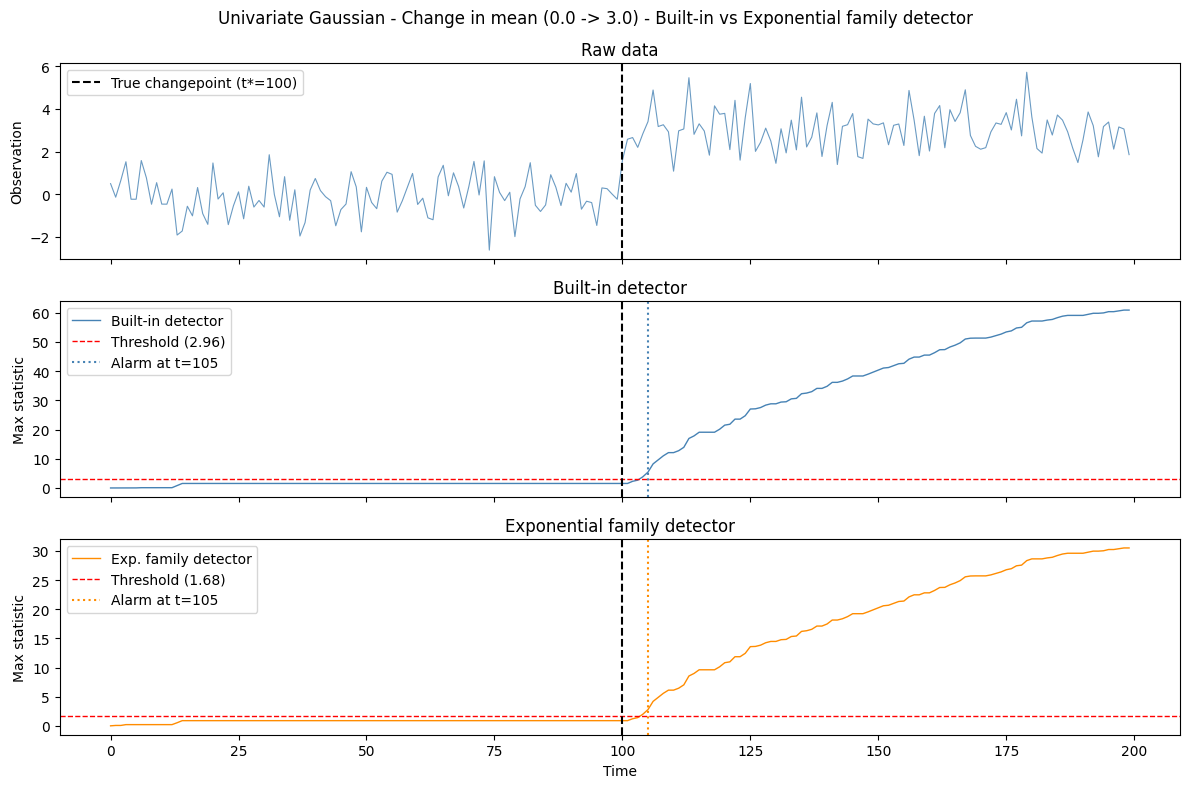


True changepoint:           t* = 100
Built-in detector alarm:    t  = 105
Exp. family detector alarm: t  = 105


In [6]:
# -----------------------------------------------------------
# 5. End-to-end test: Exponential family detector vs built-in
# -----------------------------------------------------------

import matplotlib.pyplot as plt

# Simulation settings
np.random.seed(42)
N_nvg          = 200
K_cal_nvg      = 5000
changepoint_nvg = N_nvg // 2
mu_pre         = 0.0
mu_post        = 3.0

# Simulate a single stream with a known changepoint
X = np.concatenate([
    np.random.normal(mu_pre,  1.0, changepoint_nvg),
    np.random.normal(mu_post, 1.0, N_nvg - changepoint_nvg)
])

# --- Built-in detector ---
det_builtin = make_univariate_mean_change_detector()
det_builtin.calibrate_false_alarm(
    alpha=0.05,
    N=N_nvg,
    K=K_cal_nvg,
    null_dist=np.random.normal,
    null_kwargs={"loc": 0.0, "scale": 1.0}
)
print(f"Built-in penalty constant:    {det_builtin.penalty_constant:.4f}")

# --- Exponential family detector ---
@nb.njit
def h_gaussian(x):
    return x

@nb.njit
def A_gaussian(theta):
    return theta**2 / 2.0

det_expfam = make_exponential_family_detector(
    p=1,
    h=h_gaussian,
    A=A_gaussian,
    v=1,
    A_prime=A_prime_gaussian,
    A_dprime=A_dprime_gaussian,
)
det_expfam.calibrate_false_alarm(
    alpha=0.05,
    N=N_nvg,
    K=K_cal_nvg,
    null_dist=np.random.normal,
    null_kwargs={"loc": 0.0, "scale": 1.0}
)
print(f"Exp. family penalty constant: {det_expfam.penalty_constant:.4f}")

# --- Run both detectors on the same stream ---
stats_builtin = []
t_alarm_builtin = None
for i in range(N_nvg):
    det_builtin.update(X[i])
    stats_builtin.append(det_builtin.max_statistic)
    if det_builtin.alarm and t_alarm_builtin is None:
        t_alarm_builtin = det_builtin.t

stats_expfam = []
t_alarm_expfam = None
for i in range(N_nvg):
    det_expfam.update(X[i])
    stats_expfam.append(det_expfam.max_statistic)
    if det_expfam.alarm and t_alarm_expfam is None:
        t_alarm_expfam = det_expfam.t

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fig.suptitle(f"Univariate Gaussian - Change in mean ({mu_pre} -> {mu_post}) - Built-in vs Exponential family detector")

# Panel 1: raw data
axes[0].plot(X, color="steelblue", linewidth=0.8, alpha=0.8)
axes[0].axvline(changepoint_nvg, color="black", linestyle="--", linewidth=1.5,
                label=f"True changepoint (t*={changepoint_nvg})")
axes[0].set_ylabel("Observation")
axes[0].legend(loc="upper left")
axes[0].set_title("Raw data")

# Panel 2: built-in detector
axes[1].plot(stats_builtin, color="steelblue", linewidth=1.0, label="Built-in detector")
axes[1].axhline(det_builtin.penalty_constant, color="red", linestyle="--",
                linewidth=1.0, label=f"Threshold ({det_builtin.penalty_constant:.2f})")
axes[1].axvline(changepoint_nvg, color="black", linestyle="--", linewidth=1.5)
if t_alarm_builtin is not None:
    axes[1].axvline(t_alarm_builtin, color="steelblue", linestyle=":",
                    linewidth=1.5, label=f"Alarm at t={t_alarm_builtin}")
axes[1].set_ylabel("Max statistic")
axes[1].legend(loc="upper left")
axes[1].set_title("Built-in detector")

# Panel 3: exponential family detector
axes[2].plot(stats_expfam, color="darkorange", linewidth=1.0, label="Exp. family detector")
axes[2].axhline(det_expfam.penalty_constant, color="red", linestyle="--",
                linewidth=1.0, label=f"Threshold ({det_expfam.penalty_constant:.2f})")
axes[2].axvline(changepoint_nvg, color="black", linestyle="--", linewidth=1.5)
if t_alarm_expfam is not None:
    axes[2].axvline(t_alarm_expfam, color="darkorange", linestyle=":",
                    linewidth=1.5, label=f"Alarm at t={t_alarm_expfam}")
axes[2].set_ylabel("Max statistic")
axes[2].set_xlabel("Time")
axes[2].legend(loc="upper left")
axes[2].set_title("Exponential family detector")

plt.tight_layout()
plt.show()

print(f"\nTrue changepoint:           t* = {changepoint_nvg}")
print(f"Built-in detector alarm:    t  = {t_alarm_builtin}")
print(f"Exp. family detector alarm: t  = {t_alarm_expfam}")

Running built-in detector...
Running exponential family detector...
Running built-in detector (null)...
Running exponential family detector (null)...

Metric                        Built-in  Exp. family
--------------------------------------------------
Detection rate                   0.959        0.965
False alarm rate                 0.041        0.035
Miss rate                        0.000        0.000
Mean delay                       3.021        4.365
Median delay                     3.000        4.000
Null false alarm rate            0.057        0.057
Total runtime (s)                2.691        2.801


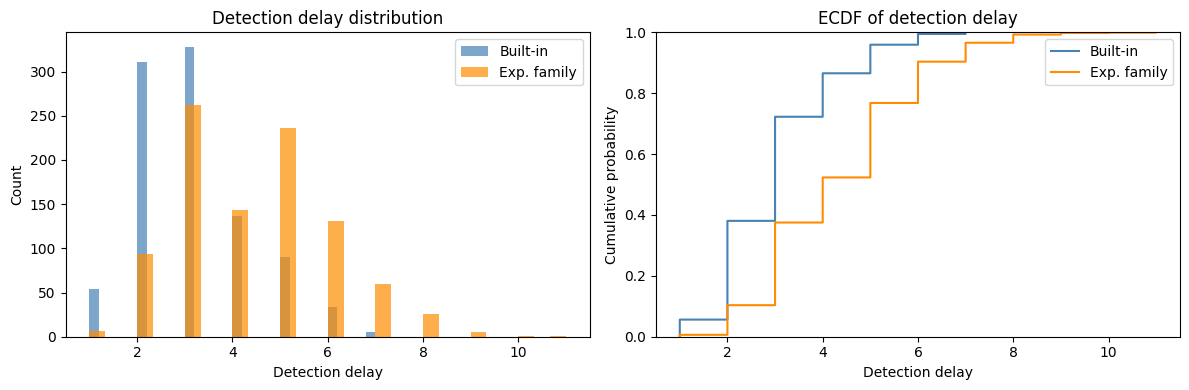

In [8]:
# -----------------------------------------------------------
# 5b. Monte Carlo comparison: built-in vs exponential family
# -----------------------------------------------------------

K_nvg = 1000

def run_simulation(detector, X_streams):
    """
    Run a detector over K streams and record alarm times.
    Resets the detector between streams rather than recreating it.
    """
    alarm_times = []
    start = time.perf_counter()
    for k in range(len(X_streams)):
        detector.reset()
        t_alarm = None
        for i in range(X_streams.shape[1]):
            detector.update(X_streams[k, i])
            if detector.alarm and t_alarm is None:
                t_alarm = detector.t
                break
        alarm_times.append(t_alarm)
    elapsed = time.perf_counter() - start
    return alarm_times, elapsed

def compute_metrics(alarm_times, t_star, N):
    alarm_times = np.array([t if t is not None else np.nan for t in alarm_times])
    detected    = alarm_times <= N
    false_alarm = alarm_times <= t_star
    miss        = np.isnan(alarm_times)
    delay       = alarm_times[detected & ~false_alarm] - t_star
    return {
        "detection_rate":   np.mean(detected & ~false_alarm),
        "false_alarm_rate": np.mean(false_alarm),
        "miss_rate":        np.mean(miss),
        "mean_delay":       np.nanmean(delay),
        "median_delay":     np.nanmedian(delay),
    }

def compute_false_alarm_rate(alarm_times):
    return np.mean([t is not None for t in alarm_times])

# --- Pre-simulate streams ---
np.random.seed(42)
X_streams = np.concatenate([
    np.random.normal(mu_pre,  1.0, (K_nvg, changepoint_nvg)),
    np.random.normal(mu_post, 1.0, (K_nvg, N_nvg - changepoint_nvg))
], axis=1)
X_null = np.random.normal(0.0, 1.0, (K_nvg, N_nvg))

# --- Run simulations ---
print("Running built-in detector...")
alarm_times_builtin, elapsed_builtin = run_simulation(det_builtin, X_streams)

print("Running exponential family detector...")
alarm_times_expfam, elapsed_expfam = run_simulation(det_expfam, X_streams)

print("Running built-in detector (null)...")
alarm_times_builtin_null, _ = run_simulation(det_builtin, X_null)

print("Running exponential family detector (null)...")
alarm_times_expfam_null, _ = run_simulation(det_expfam, X_null)

# --- Compute metrics ---
metrics_builtin = compute_metrics(alarm_times_builtin, changepoint_nvg, N_nvg)
metrics_expfam  = compute_metrics(alarm_times_expfam,  changepoint_nvg, N_nvg)
far_builtin     = compute_false_alarm_rate(alarm_times_builtin_null)
far_expfam      = compute_false_alarm_rate(alarm_times_expfam_null)

# --- Print results ---
print(f"\n{'Metric':<25} {'Built-in':>12} {'Exp. family':>12}")
print("-" * 50)
print(f"{'Detection rate':<25} {metrics_builtin['detection_rate']:>12.3f} {metrics_expfam['detection_rate']:>12.3f}")
print(f"{'False alarm rate':<25} {metrics_builtin['false_alarm_rate']:>12.3f} {metrics_expfam['false_alarm_rate']:>12.3f}")
print(f"{'Miss rate':<25} {metrics_builtin['miss_rate']:>12.3f} {metrics_expfam['miss_rate']:>12.3f}")
print(f"{'Mean delay':<25} {metrics_builtin['mean_delay']:>12.3f} {metrics_expfam['mean_delay']:>12.3f}")
print(f"{'Median delay':<25} {metrics_builtin['median_delay']:>12.3f} {metrics_expfam['median_delay']:>12.3f}")
print(f"{'Null false alarm rate':<25} {far_builtin:>12.3f} {far_expfam:>12.3f}")
print(f"{'Total runtime (s)':<25} {elapsed_builtin:>12.3f} {elapsed_expfam:>12.3f}")

# --- Plot: detection delay distributions ---
delays_builtin = [t - changepoint_nvg for t in alarm_times_builtin
                  if t is not None and t > changepoint_nvg]
delays_expfam  = [t - changepoint_nvg for t in alarm_times_expfam
                  if t is not None and t > changepoint_nvg]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(delays_builtin, bins=30, color="steelblue", alpha=0.7, label="Built-in")
axes[0].hist(delays_expfam,  bins=30, color="darkorange", alpha=0.7, label="Exp. family")
axes[0].set_xlabel("Detection delay")
axes[0].set_ylabel("Count")
axes[0].set_title("Detection delay distribution")
axes[0].legend()

axes[1].ecdf(delays_builtin, color="steelblue", label="Built-in")
axes[1].ecdf(delays_expfam,  color="darkorange", label="Exp. family")
axes[1].set_xlabel("Detection delay")
axes[1].set_ylabel("Cumulative probability")
axes[1].set_title("ECDF of detection delay")
axes[1].legend()

plt.tight_layout()
plt.show()

Built-in penalty constant:    3.2003
Exp. family penalty constant: 1.9474
Running built-in multivariate detector...
Running exponential family multivariate detector...
Running built-in multivariate detector (null)...
Running exponential family multivariate detector (null)...

Metric                        Built-in  Exp. family
--------------------------------------------------
Detection rate                   0.960        0.957
False alarm rate                 0.040        0.043
Miss rate                        0.000        0.000
Mean delay                      12.276       26.671
Median delay                    12.000       26.000
Null false alarm rate            0.052        0.053
Total runtime (s)                2.882        5.486


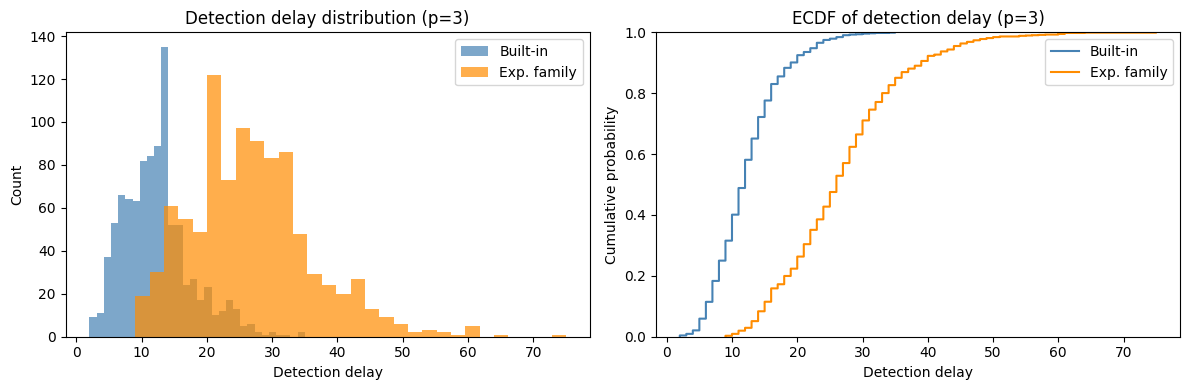

In [9]:
# -----------------------------------------------------------
# 5c. Multivariate test: exponential family vs built-in
# -----------------------------------------------------------

p_mv = 3
mu_pre_mv  = np.zeros(p_mv)
mu_post_mv = np.ones(p_mv)

# --- Built-in multivariate detector ---
det_builtin_mv = make_multivariate_mean_change_detector(p=p_mv, mode="known_variance")
det_builtin_mv.calibrate_false_alarm(
    alpha=0.05,
    N=N_nvg,
    K=K_cal_nvg,
    null_dist=np.random.multivariate_normal,
    null_kwargs={"mean": mu_pre_mv, "cov": np.eye(p_mv)}
)
print(f"Built-in penalty constant:    {det_builtin_mv.penalty_constant:.4f}")

# --- Exponential family multivariate detector ---
@nb.njit
def h_mv_gaussian(x):
    return x.copy()

@nb.njit
def A_mv_gaussian(theta):
    result = 0.0
    for i in range(len(theta)):
        result += theta[i] ** 2
    return result / 2.0

det_expfam_mv = make_exponential_family_detector(
    p=p_mv,
    h=h_mv_gaussian,
    A=A_mv_gaussian,
    v=p_mv,
    A_grad=A_grad_mvgaussian,
    A_hess=A_hess_mvgaussian,
    penalty_constant=1.0,
)
det_expfam_mv.calibrate_false_alarm(
    alpha=0.05,
    N=N_nvg,
    K=K_cal_nvg,
    null_dist=np.random.multivariate_normal,
    null_kwargs={"mean": mu_pre_mv, "cov": np.eye(p_mv)}
)
print(f"Exp. family penalty constant: {det_expfam_mv.penalty_constant:.4f}")

# --- Pre-simulate streams ---
np.random.seed(42)
X_streams_mv = np.concatenate([
    np.random.multivariate_normal(mu_pre_mv,  np.eye(p_mv), (K_nvg, changepoint_nvg)).reshape(K_nvg, changepoint_nvg, p_mv),
    np.random.multivariate_normal(mu_post_mv, np.eye(p_mv), (K_nvg, N_nvg - changepoint_nvg)).reshape(K_nvg, N_nvg - changepoint_nvg, p_mv),
], axis=1)

X_null_mv = np.random.multivariate_normal(mu_pre_mv, np.eye(p_mv), (K_nvg, N_nvg)).reshape(K_nvg, N_nvg, p_mv)

# --- Run simulations ---
print("Running built-in multivariate detector...")
alarm_times_builtin_mv, elapsed_builtin_mv = run_simulation(det_builtin_mv, X_streams_mv)

print("Running exponential family multivariate detector...")
alarm_times_expfam_mv, elapsed_expfam_mv = run_simulation(det_expfam_mv, X_streams_mv)

print("Running built-in multivariate detector (null)...")
alarm_times_builtin_mv_null, _ = run_simulation(det_builtin_mv, X_null_mv)

print("Running exponential family multivariate detector (null)...")
alarm_times_expfam_mv_null, _ = run_simulation(det_expfam_mv, X_null_mv)

# --- Compute metrics ---
metrics_builtin_mv = compute_metrics(alarm_times_builtin_mv, changepoint_nvg, N_nvg)
metrics_expfam_mv  = compute_metrics(alarm_times_expfam_mv,  changepoint_nvg, N_nvg)
far_builtin_mv     = compute_false_alarm_rate(alarm_times_builtin_mv_null)
far_expfam_mv      = compute_false_alarm_rate(alarm_times_expfam_mv_null)

# --- Print results ---
print(f"\n{'Metric':<25} {'Built-in':>12} {'Exp. family':>12}")
print("-" * 50)
print(f"{'Detection rate':<25} {metrics_builtin_mv['detection_rate']:>12.3f} {metrics_expfam_mv['detection_rate']:>12.3f}")
print(f"{'False alarm rate':<25} {metrics_builtin_mv['false_alarm_rate']:>12.3f} {metrics_expfam_mv['false_alarm_rate']:>12.3f}")
print(f"{'Miss rate':<25} {metrics_builtin_mv['miss_rate']:>12.3f} {metrics_expfam_mv['miss_rate']:>12.3f}")
print(f"{'Mean delay':<25} {metrics_builtin_mv['mean_delay']:>12.3f} {metrics_expfam_mv['mean_delay']:>12.3f}")
print(f"{'Median delay':<25} {metrics_builtin_mv['median_delay']:>12.3f} {metrics_expfam_mv['median_delay']:>12.3f}")
print(f"{'Null false alarm rate':<25} {far_builtin_mv:>12.3f} {far_expfam_mv:>12.3f}")
print(f"{'Total runtime (s)':<25} {elapsed_builtin_mv:>12.3f} {elapsed_expfam_mv:>12.3f}")

# --- Plot: detection delay distributions ---
delays_builtin_mv = [t - changepoint_nvg for t in alarm_times_builtin_mv
                     if t is not None and t > changepoint_nvg]
delays_expfam_mv  = [t - changepoint_nvg for t in alarm_times_expfam_mv
                     if t is not None and t > changepoint_nvg]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(delays_builtin_mv, bins=30, color="steelblue", alpha=0.7, label="Built-in")
axes[0].hist(delays_expfam_mv,  bins=30, color="darkorange", alpha=0.7, label="Exp. family")
axes[0].set_xlabel("Detection delay")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Detection delay distribution (p={p_mv})")
axes[0].legend()

axes[1].ecdf(delays_builtin_mv, color="steelblue", label="Built-in")
axes[1].ecdf(delays_expfam_mv,  color="darkorange", label="Exp. family")
axes[1].set_xlabel("Detection delay")
axes[1].set_ylabel("Cumulative probability")
axes[1].set_title(f"ECDF of detection delay (p={p_mv})")
axes[1].legend()

plt.tight_layout()
plt.show()

Poisson penalty constant: 1.8173
Running Poisson detector...
Exponential penalty constant: 1.7715
Running Exponential detector...
Bernoulli penalty constant: 1.3877
Running Bernoulli detector...

Metric                         Poisson  Exponential    Bernoulli
-----------------------------------------------------------------
Detection rate                   0.951        0.931        0.860
False alarm rate                 0.049        0.059        0.051
Miss rate                        0.000        0.010        0.089
Mean delay                       6.297       39.675       39.699
Median delay                     6.000       36.000       35.000
Null false alarm rate            0.036        0.055        0.047
Total runtime (s)                3.083        3.895        4.549


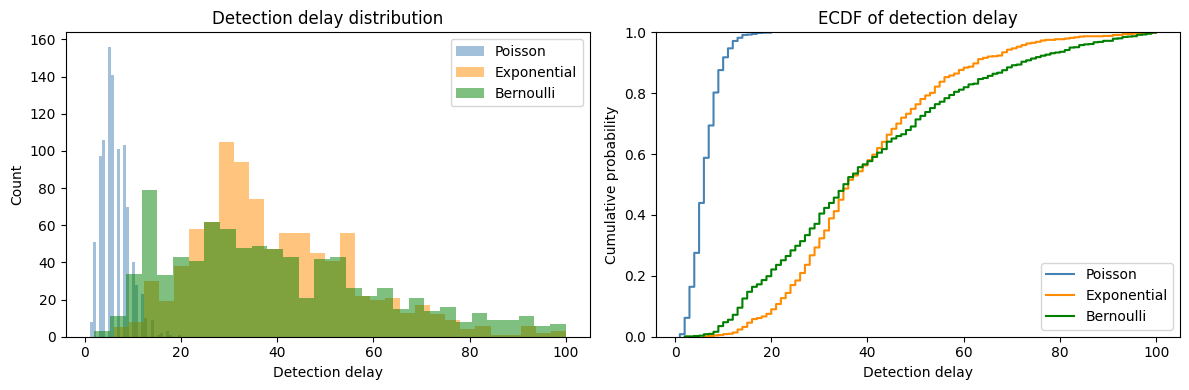

In [15]:
# -----------------------------------------------------------
# 6. Tests on new exponential families
# -----------------------------------------------------------

# -----------------------------------------------------------
# 6a. Poisson
#
# theta = log(lambda)
# h(x)  = x
# A(theta) = exp(theta)
# A'(theta) = exp(theta)
# A''(theta) = exp(theta)
# MLE: theta_hat = log(x_bar)
# -----------------------------------------------------------

@nb.njit
def h_poisson(x):
    return x

@nb.njit
def A_poisson(theta):
    return np.exp(theta)

@nb.njit
def A_prime_poisson(theta):
    return np.exp(theta)

@nb.njit
def A_dprime_poisson(theta):
    return np.exp(theta)

# Simulation settings
lambda_pre  = 2.0
lambda_post = 6.0

det_poisson = make_exponential_family_detector(
    p=1,
    h=h_poisson,
    A=A_poisson,
    v=1,
    A_prime=A_prime_poisson,
    A_dprime=A_dprime_poisson,
)
det_poisson.calibrate_false_alarm(
    alpha=0.05,
    N=N_nvg,
    K=K_cal_nvg,
    null_dist=np.random.poisson,
    null_kwargs={"lam": lambda_pre}
)
print(f"Poisson penalty constant: {det_poisson.penalty_constant:.4f}")

# Pre-simulate streams
np.random.seed(42)
X_streams_poisson = np.concatenate([
    np.random.poisson(lambda_pre,  (K_nvg, changepoint_nvg)),
    np.random.poisson(lambda_post, (K_nvg, N_nvg - changepoint_nvg))
], axis=1).astype(float)
X_null_poisson = np.random.poisson(lambda_pre, (K_nvg, N_nvg)).astype(float)

# Run simulations
print("Running Poisson detector...")
alarm_times_poisson, elapsed_poisson = run_simulation(det_poisson, X_streams_poisson)
alarm_times_poisson_null, _          = run_simulation(det_poisson, X_null_poisson)

metrics_poisson = compute_metrics(alarm_times_poisson, changepoint_nvg, N_nvg)
far_poisson     = compute_false_alarm_rate(alarm_times_poisson_null)

# -----------------------------------------------------------
# 6b. Exponential
#
# theta = -beta  (beta = rate)
# h(x)  = x
# A(theta) = -log(-theta)
# A'(theta) = -1/theta
# A''(theta) = 1/theta^2
# MLE: theta_hat = -1/x_bar
# -----------------------------------------------------------

@nb.njit
def h_exponential(x):
    return x

@nb.njit
def A_exponential(theta):
    return -np.log(-theta)

@nb.njit
def A_prime_exponential(theta):
    return -1.0 / theta

@nb.njit
def A_dprime_exponential(theta):
    return 1.0 / theta**2

# Simulation settings
beta_pre  = 1.0
beta_post = 3.0

det_exponential = make_exponential_family_detector(
    p=1,
    h=h_exponential,
    A=A_exponential,
    v=1,
    A_prime=A_prime_exponential,
    A_dprime=A_dprime_exponential,
    theta_init=-1.0,  # theta = -beta, so theta < 0 always
)
det_exponential.calibrate_false_alarm(
    alpha=0.05,
    N=N_nvg,
    K=K_cal_nvg,
    null_dist=np.random.exponential,
    null_kwargs={"scale": 1.0 / beta_pre}
)
print(f"Exponential penalty constant: {det_exponential.penalty_constant:.4f}")

# Pre-simulate streams
np.random.seed(42)
X_streams_exponential = np.concatenate([
    np.random.exponential(1.0 / beta_pre,  (K_nvg, changepoint_nvg)),
    np.random.exponential(1.0 / beta_post, (K_nvg, N_nvg - changepoint_nvg))
], axis=1)
X_null_exponential = np.random.exponential(1.0 / beta_pre, (K_nvg, N_nvg))

# Run simulations
print("Running Exponential detector...")
alarm_times_exponential, elapsed_exponential = run_simulation(det_exponential, X_streams_exponential)
alarm_times_exponential_null, _              = run_simulation(det_exponential, X_null_exponential)

metrics_exponential = compute_metrics(alarm_times_exponential, changepoint_nvg, N_nvg)
far_exponential     = compute_false_alarm_rate(alarm_times_exponential_null)

# -----------------------------------------------------------
# 6c. Bernoulli
#
# theta = log(p / (1-p))  (log-odds)
# h(x)  = x
# A(theta) = log(1 + exp(theta))
# A'(theta) = exp(theta) / (1 + exp(theta))
# A''(theta) = exp(theta) / (1 + exp(theta))^2
# MLE: theta_hat = log(x_bar / (1 - x_bar))
# -----------------------------------------------------------

@nb.njit
def h_bernoulli(x):
    return x

@nb.njit
def A_bernoulli(theta):
    return np.log(1.0 + np.exp(theta))

@nb.njit
def A_prime_bernoulli(theta):
    e = np.exp(theta)
    return e / (1.0 + e)

@nb.njit
def A_dprime_bernoulli(theta):
    e = np.exp(theta)
    return e / (1.0 + e)**2

# Simulation settings
p_pre  = 0.3
p_post = 0.7

det_bernoulli = make_exponential_family_detector(
    p=1,
    h=h_bernoulli,
    A=A_bernoulli,
    v=1,
    A_prime=A_prime_bernoulli,
    A_dprime=A_dprime_bernoulli,
)
det_bernoulli.calibrate_false_alarm(
    alpha=0.05,
    N=N_nvg,
    K=K_cal_nvg,
    null_dist=np.random.binomial,
    null_kwargs={"n": 1, "p": p_pre}
)
print(f"Bernoulli penalty constant: {det_bernoulli.penalty_constant:.4f}")

# Pre-simulate streams
np.random.seed(42)
X_streams_bernoulli = np.concatenate([
    np.random.binomial(1, p_pre,  (K_nvg, changepoint_nvg)),
    np.random.binomial(1, p_post, (K_nvg, N_nvg - changepoint_nvg))
], axis=1).astype(float)
X_null_bernoulli = np.random.binomial(1, p_pre, (K_nvg, N_nvg)).astype(float)

# Run simulations
print("Running Bernoulli detector...")
alarm_times_bernoulli, elapsed_bernoulli = run_simulation(det_bernoulli, X_streams_bernoulli)
alarm_times_bernoulli_null, _            = run_simulation(det_bernoulli, X_null_bernoulli)

metrics_bernoulli = compute_metrics(alarm_times_bernoulli, changepoint_nvg, N_nvg)
far_bernoulli     = compute_false_alarm_rate(alarm_times_bernoulli_null)

# -----------------------------------------------------------
# Print results
# -----------------------------------------------------------
print(f"\n{'Metric':<25} {'Poisson':>12} {'Exponential':>12} {'Bernoulli':>12}")
print("-" * 65)
print(f"{'Detection rate':<25} {metrics_poisson['detection_rate']:>12.3f} {metrics_exponential['detection_rate']:>12.3f} {metrics_bernoulli['detection_rate']:>12.3f}")
print(f"{'False alarm rate':<25} {metrics_poisson['false_alarm_rate']:>12.3f} {metrics_exponential['false_alarm_rate']:>12.3f} {metrics_bernoulli['false_alarm_rate']:>12.3f}")
print(f"{'Miss rate':<25} {metrics_poisson['miss_rate']:>12.3f} {metrics_exponential['miss_rate']:>12.3f} {metrics_bernoulli['miss_rate']:>12.3f}")
print(f"{'Mean delay':<25} {metrics_poisson['mean_delay']:>12.3f} {metrics_exponential['mean_delay']:>12.3f} {metrics_bernoulli['mean_delay']:>12.3f}")
print(f"{'Median delay':<25} {metrics_poisson['median_delay']:>12.3f} {metrics_exponential['median_delay']:>12.3f} {metrics_bernoulli['median_delay']:>12.3f}")
print(f"{'Null false alarm rate':<25} {far_poisson:>12.3f} {far_exponential:>12.3f} {far_bernoulli:>12.3f}")
print(f"{'Total runtime (s)':<25} {elapsed_poisson:>12.3f} {elapsed_exponential:>12.3f} {elapsed_bernoulli:>12.3f}")

# -----------------------------------------------------------
# Plot
# -----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

delays_poisson     = [t - changepoint_nvg for t in alarm_times_poisson
                      if t is not None and t > changepoint_nvg]
delays_exponential = [t - changepoint_nvg for t in alarm_times_exponential
                      if t is not None and t > changepoint_nvg]
delays_bernoulli   = [t - changepoint_nvg for t in alarm_times_bernoulli
                      if t is not None and t > changepoint_nvg]

axes[0].hist(delays_poisson,     bins=30, color="steelblue",  alpha=0.5, label="Poisson")
axes[0].hist(delays_exponential, bins=30, color="darkorange", alpha=0.5, label="Exponential")
axes[0].hist(delays_bernoulli,   bins=30, color="green",      alpha=0.5, label="Bernoulli")
axes[0].set_xlabel("Detection delay")
axes[0].set_ylabel("Count")
axes[0].set_title("Detection delay distribution")
axes[0].legend()

axes[1].ecdf(delays_poisson,     color="steelblue",  label="Poisson")
axes[1].ecdf(delays_exponential, color="darkorange", label="Exponential")
axes[1].ecdf(delays_bernoulli,   color="green",      label="Bernoulli")
axes[1].set_xlabel("Detection delay")
axes[1].set_ylabel("Cumulative probability")
axes[1].set_title("ECDF of detection delay")
axes[1].legend()

plt.tight_layout()
plt.show()

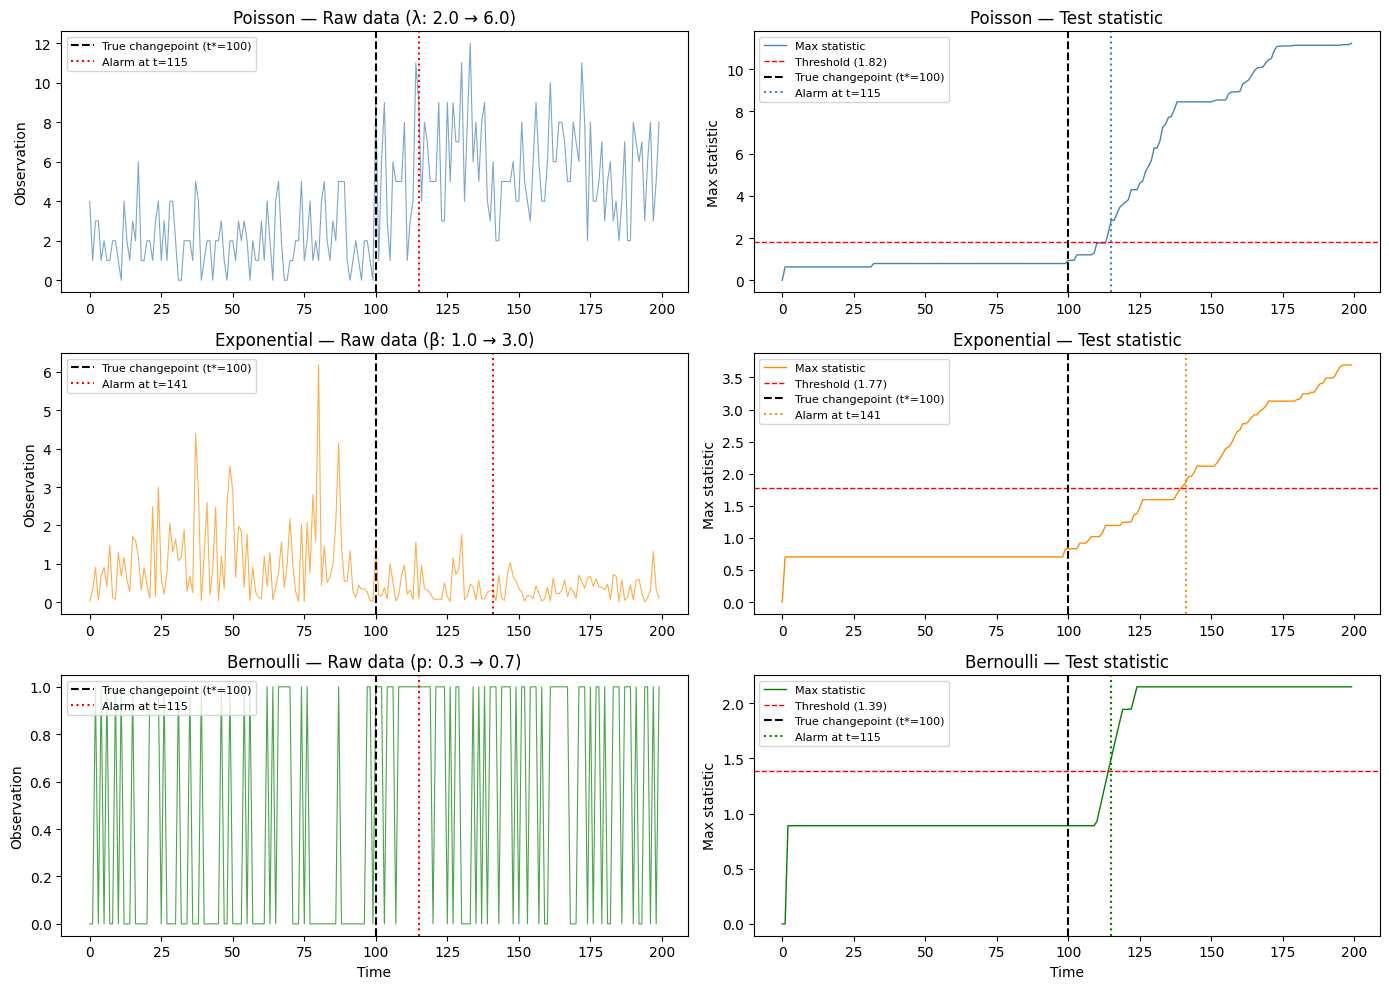

In [14]:
# -----------------------------------------------------------
# 6d. Single-stream plots: test statistic over time
# -----------------------------------------------------------

np.random.seed(42)

# Simulate single streams
X_poisson_single = np.concatenate([
    np.random.poisson(lambda_pre,  changepoint_nvg),
    np.random.poisson(lambda_post, N_nvg - changepoint_nvg)
]).astype(float)

X_exponential_single = np.concatenate([
    np.random.exponential(1.0 / beta_pre,  changepoint_nvg),
    np.random.exponential(1.0 / beta_post, N_nvg - changepoint_nvg)
])

X_bernoulli_single = np.concatenate([
    np.random.binomial(1, p_pre,  changepoint_nvg),
    np.random.binomial(1, p_post, N_nvg - changepoint_nvg)
]).astype(float)

# Run detectors and record statistics
def collect_stats(detector, X):
    detector.reset()
    stats = []
    t_alarm = None
    for i in range(len(X)):
        detector.update(X[i])
        stats.append(detector.max_statistic)
        if detector.alarm and t_alarm is None:
            t_alarm = detector.t
    return stats, t_alarm

stats_poisson,     t_alarm_poisson     = collect_stats(det_poisson,     X_poisson_single)
stats_exponential, t_alarm_exponential = collect_stats(det_exponential, X_exponential_single)
stats_bernoulli,   t_alarm_bernoulli   = collect_stats(det_bernoulli,   X_bernoulli_single)

# --- Plot ---
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=False)

families = [
    ("Poisson",     X_poisson_single,     stats_poisson,     t_alarm_poisson,
     det_poisson.penalty_constant,     "steelblue",  f"λ: {lambda_pre} → {lambda_post}"),
    ("Exponential", X_exponential_single, stats_exponential, t_alarm_exponential,
     det_exponential.penalty_constant, "darkorange", f"β: {beta_pre} → {beta_post}"),
    ("Bernoulli",   X_bernoulli_single,   stats_bernoulli,   t_alarm_bernoulli,
     det_bernoulli.penalty_constant,   "green",      f"p: {p_pre} → {p_post}"),
]

for row, (name, X, stats, t_alarm, threshold, color, label) in enumerate(families):
    # Left: raw data
    axes[row, 0].plot(X, color=color, linewidth=0.8, alpha=0.7)
    axes[row, 0].axvline(changepoint_nvg, color="black", linestyle="--",
                         linewidth=1.5, label=f"True changepoint (t*={changepoint_nvg})")
    if t_alarm is not None:
        axes[row, 0].axvline(t_alarm, color="red", linestyle=":",
                             linewidth=1.5, label=f"Alarm at t={t_alarm}")
    axes[row, 0].set_title(f"{name} — Raw data ({label})")
    axes[row, 0].set_ylabel("Observation")
    axes[row, 0].legend(loc="upper left", fontsize=8)

    # Right: test statistic
    axes[row, 1].plot(stats, color=color, linewidth=1.0, label="Max statistic")
    axes[row, 1].axhline(threshold, color="red", linestyle="--",
                         linewidth=1.0, label=f"Threshold ({threshold:.2f})")
    axes[row, 1].axvline(changepoint_nvg, color="black", linestyle="--",
                         linewidth=1.5, label=f"True changepoint (t*={changepoint_nvg})")
    if t_alarm is not None:
        axes[row, 1].axvline(t_alarm, color=color, linestyle=":",
                             linewidth=1.5, label=f"Alarm at t={t_alarm}")
    axes[row, 1].set_title(f"{name} — Test statistic")
    axes[row, 1].set_ylabel("Max statistic")
    axes[row, 1].legend(loc="upper left", fontsize=8)

for ax in axes[-1]:
    ax.set_xlabel("Time")

plt.tight_layout()
plt.show()

## 6e. False alarm control check: one long null stream

In [7]:
# -----------------------------------------------------------
# 6e. False alarm control check: one long null stream
#
# Goal:
# - Calibrate each detector at N_cal = 1000 under the null.
# - Run one long null stream (N_long = 100000).
# - Store both instantaneous and cumulative-max traces.
# -----------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# --- Settings ---
N_CAL = 1_000
K_CAL = 2_000
N_LONG = 100_000
SEED = 12345


def collect_lr_vs_threshold_trace(detector, x_stream):
    """
    Collect per-time traces from a detector run:
    - lr_best[t]: raw LR (f value) for the candidate maximizing f/penalty at time t
    - thr_best[t]: lambda * penalty for that same maximizing candidate
    - ratio_best[t]: max f/penalty at time t
    - stat_running[t]: detector's running max statistic (monotone)
    - lr_running[t]: cumulative max of lr_best (monotone)
    - thr_running[t]: cumulative max of thr_best (monotone)
    """
    detector.reset()

    n = len(x_stream)
    lr_best = np.full(n, np.nan)
    thr_best = np.full(n, np.nan)
    ratio_best = np.full(n, np.nan)
    stat_running = np.full(n, np.nan)

    first_alarm = None

    for i in range(n):
        detector.update(x_stream[i])

        # This is the detector's test statistic: running maximum over time.
        stat_running[i] = detector.max_statistic

        if detector.alarm and first_alarm is None:
            first_alarm = detector.t

        state = detector._state
        t = state["t"]

        if t <= 1 or len(state["grid_list"]) == 0:
            continue

        S_total = state["sum"]
        p = state["p"]
        f_fn = state["f"]
        pen_fn = state["penalty"]
        lam = state["penalty_constant"]

        best_ratio = -np.inf
        best_lr = np.nan
        best_thr = np.nan

        for j in range(len(state["grid_list"]) - 1, -1, -1):
            g = state["grid_list"][j] + t + 1
            b = t - g

            S_pre = state["sum_pre_list"][j]
            S_post = S_total - S_pre

            pen = pen_fn(b, t, p)
            if pen <= 0.0:
                continue

            lr = f_fn(S_pre, S_post, b, t)
            ratio = lr / pen

            if ratio > best_ratio:
                best_ratio = ratio
                best_lr = lr
                best_thr = lam * pen

        lr_best[i] = best_lr
        thr_best[i] = best_thr
        ratio_best[i] = best_ratio

    lr_running = np.maximum.accumulate(np.nan_to_num(lr_best, nan=0.0))
    thr_running = np.maximum.accumulate(np.nan_to_num(thr_best, nan=0.0))

    return {
        "lr": lr_best,
        "threshold": thr_best,
        "ratio": ratio_best,
        "stat_running": stat_running,
        "lr_running": lr_running,
        "threshold_running": thr_running,
        "first_alarm": first_alarm,
        "lambda": detector.penalty_constant,
    }


# --- Build and calibrate detectors for this experiment ---
det_builtin_long = make_univariate_mean_change_detector()
det_builtin_long.calibrate_false_alarm(
    alpha=0.05,
    N=N_CAL,
    K=K_CAL,
    null_dist=np.random.normal,
    null_kwargs={"loc": 0.0, "scale": 1.0},
)

# Reuse the same exponential-family specification used earlier.
det_expfam_long = make_exponential_family_detector(
    p=1,
    h=h_gaussian,
    A=A_gaussian,
    v=1,
    A_prime=A_prime_gaussian,
    A_dprime=A_dprime_gaussian,
)
det_expfam_long.calibrate_false_alarm(
    alpha=0.05,
    N=N_CAL,
    K=K_CAL,
    null_dist=np.random.normal,
    null_kwargs={"loc": 0.0, "scale": 1.0},
)

print(f"Built-in lambda (N_cal={N_CAL}):   {det_builtin_long.penalty_constant:.4f}")
print(f"Exp. family lambda (N_cal={N_CAL}): {det_expfam_long.penalty_constant:.4f}")

# --- One shared long null stream ---
rng = np.random.default_rng(SEED)
X_long_null = rng.normal(0.0, 1.0, N_LONG)

a = time.perf_counter()
trace_builtin = collect_lr_vs_threshold_trace(det_builtin_long, X_long_null)
elapsed_builtin = time.perf_counter() - a
print(f"Built-in long stream runtime: {elapsed_builtin:.2f} seconds")
trace_expfam = collect_lr_vs_threshold_trace(det_expfam_long, X_long_null)


Built-in lambda (N_cal=1000):   2.9488
Exp. family lambda (N_cal=1000): 1.6759
Built-in long stream runtime: 13.85 seconds


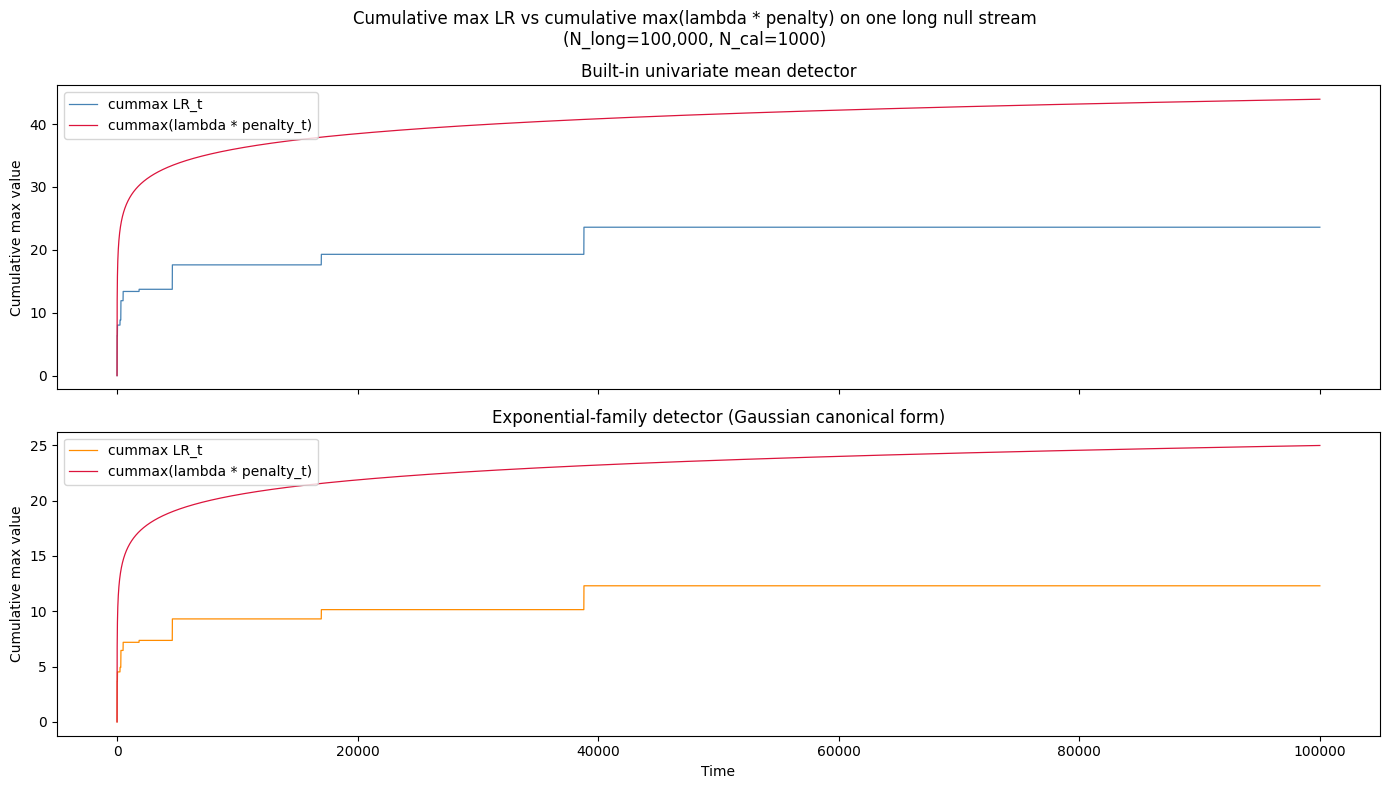


Built-in first alarm time:    None
Exp. family first alarm time: None
Stored monotone test statistic arrays:
  trace_builtin['stat_running'], trace_expfam['stat_running']


In [ ]:
time_axis = np.arange(1, N_LONG + 1)

# Use cumulative maxima so both lines are monotone increasing.
lr_builtin_max = trace_builtin.get("lr_running", np.maximum.accumulate(np.nan_to_num(trace_builtin["lr"], nan=0.0)))
thr_builtin_max = trace_builtin.get("threshold_running", np.maximum.accumulate(np.nan_to_num(trace_builtin["threshold"], nan=0.0)))

lr_expfam_max = trace_expfam.get("lr_running", np.maximum.accumulate(np.nan_to_num(trace_expfam["lr"], nan=0.0)))
thr_expfam_max = trace_expfam.get("threshold_running", np.maximum.accumulate(np.nan_to_num(trace_expfam["threshold"], nan=0.0)))

# --- Plot: cumulative maxima ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle(
    f"Cumulative max f vs cumulative max(lambda * penalty) on one long null stream\n"
    f"(N_long={N_LONG:,}, N_cal={N_CAL})"
)

axes[0].plot(time_axis, lr_builtin_max, color="steelblue", linewidth=0.9, label="cummax LR_t")
axes[0].plot(time_axis, thr_builtin_max, color="crimson", linewidth=0.9, label="cummax(lambda * penalty_t)")
if trace_builtin["first_alarm"] is not None:
    axes[0].axvline(trace_builtin["first_alarm"], color="black", linestyle=":", linewidth=1.0)
axes[0].set_title("Built-in univariate mean detector")
axes[0].set_ylabel("Cumulative max value")
axes[0].legend(loc="upper left")

axes[1].plot(time_axis, lr_expfam_max, color="darkorange", linewidth=0.9, label="cummax LR_t")
axes[1].plot(time_axis, thr_expfam_max, color="crimson", linewidth=0.9, label="cummax(lambda * penalty_t)")
if trace_expfam["first_alarm"] is not None:
    axes[1].axvline(trace_expfam["first_alarm"], color="black", linestyle=":", linewidth=1.0)
axes[1].set_title("Exponential-family detector (Gaussian canonical form)")
axes[1].set_ylabel("Cumulative max value")
axes[1].set_xlabel("Time")
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()

print(f"\nBuilt-in first alarm time:    {trace_builtin['first_alarm']}")
print(f"Exp. family first alarm time: {trace_expfam['first_alarm']}")
print("Stored monotone test statistic arrays:")
print("  trace_builtin['stat_running'], trace_expfam['stat_running']")

**False alarm rate over time from repeated long null runs (built-in only)**

In [5]:
# -----------------------------------------------------------
# 6f. Monte Carlo false alarm control (built-in only)
# Full-pass simulation with disk-backed storage for plot variables
# -----------------------------------------------------------

import json
import numpy as np
from pathlib import Path
from time import perf_counter

# --- Settings ---
K_MC = 10
N_MC = 100_000
#SEED_MC = 20260317
ALPHA_TARGET = 0.05

# Calibration for this FAR experiment
N_CAL_FAR = 1_000
K_CAL_FAR = 2_000

# FAR checkpoints
T_CHECK = np.array([1_000, 5_000, 10_000, 50_000, 100_000], dtype=np.int64)
T_CHECK = T_CHECK[T_CHECK <= N_MC]

# --- Output paths for crash-safe persistence ---
results_dir = Path("results") / "mc_far_builtin"
results_dir.mkdir(parents=True, exist_ok=True)
stat_paths_file = results_dir / "stat_paths.npy"
summary_file = results_dir / "mc_far_summary.npz"
meta_file = results_dir / "mc_far_meta.json"

# --- Build and calibrate built-in detector ---
det_builtin_far = make_univariate_mean_change_detector()
det_builtin_far.calibrate_false_alarm(
    alpha=ALPHA_TARGET,
    N=N_CAL_FAR,
    K=K_CAL_FAR,
    null_dist=np.random.normal,
    null_kwargs={"loc": 0.0, "scale": 1.0},
)

lambda_far = det_builtin_far.penalty_constant
print(f"Built-in lambda (N_cal={N_CAL_FAR}): {lambda_far:.4f}")

# --- Monte Carlo under null (full pass, no early stop) ---
rng_mc = np.random.default_rng()

# Use a memory-mapped .npy array so paths survive crashes and avoid huge RAM usage.
stat_paths = np.lib.format.open_memmap(
    stat_paths_file,
    mode="w+",
    dtype=np.float32,
    shape=(K_MC, N_MC),
)

# First alarm time for FAR summaries; N_MC + 1 means no alarm by horizon.
first_alarm_times = np.full(K_MC, N_MC + 1, dtype=np.int64)

start = perf_counter()
for k in range(K_MC):
    x_null = rng_mc.normal(0.0, 1.0, N_MC)
    det_builtin_far.reset()

    t_alarm = N_MC + 1
    for i, x in enumerate(x_null, start=1):
        det_builtin_far.update(x)
        stat_paths[k, i - 1] = det_builtin_far.max_statistic

        if t_alarm == N_MC + 1 and det_builtin_far.alarm:
            t_alarm = i

    first_alarm_times[k] = t_alarm

    if (k + 1) % 25 == 0:
        stat_paths.flush()
        print(f"Completed {k + 1}/{K_MC} streams")

stat_paths.flush()
elapsed_mc = perf_counter() - start
print(f"Full Monte Carlo runtime: {elapsed_mc:.2f} seconds")

# --- FAR summaries from stored first_alarm_times ---
far_at_checkpoints = np.array(
    [np.mean(first_alarm_times <= t_check) for t_check in T_CHECK],
    dtype=np.float64,
)

# Full FAR curve (for optional background line).
time_mc = np.arange(1, N_MC + 1)
far_t_builtin = np.array(
    [np.mean(first_alarm_times <= t) for t in time_mc],
    dtype=np.float64,
)
far_final_builtin = far_t_builtin[-1]

# Final max statistic per stream (used by downstream fit plots).
final_max_stats = np.array(stat_paths[:, -1], dtype=np.float64)
mean_stat_path = np.array(np.mean(stat_paths, axis=0), dtype=np.float64)

# Save lightweight summary bundle for quick reload after restart/crash.
np.savez_compressed(
    summary_file,
    first_alarm_times=first_alarm_times,
    T_CHECK=T_CHECK,
    far_at_checkpoints=far_at_checkpoints,
    time_mc=time_mc,
    far_t_builtin=far_t_builtin,
    final_max_stats=final_max_stats,
    mean_stat_path=mean_stat_path,
    lambda_far=np.array([lambda_far], dtype=np.float64),
    alpha_target=np.array([ALPHA_TARGET], dtype=np.float64),
    K_MC=np.array([K_MC], dtype=np.int64),
    N_MC=np.array([N_MC], dtype=np.int64),
)

meta_payload = {
    "stat_paths_file": str(stat_paths_file),
    "summary_file": str(summary_file),
    "shape": [int(K_MC), int(N_MC)],
    "dtype": "float32",
    "note": "Use np.load(stat_paths_file, mmap_mode='r') to read without loading whole array into RAM."
}
meta_file.write_text(json.dumps(meta_payload, indent=2))

print(f"Saved stream paths to: {stat_paths_file}")
print(f"Saved summary arrays to: {summary_file}")
print(f"Saved metadata to: {meta_file}")

Built-in lambda (N_cal=1000): 2.9488
Full Monte Carlo runtime: 29.61 seconds
Saved stream paths to: results/mc_far_builtin/stat_paths.npy
Saved summary arrays to: results/mc_far_builtin/mc_far_summary.npz
Saved metadata to: results/mc_far_builtin/mc_far_meta.json


In [ ]:
# Optional recovery cell: run this if kernel restarted and you want to re-plot without re-simulating.
from pathlib import Path
import numpy as np

def _human_size(n_bytes: int) -> str:
    units = ["B", "KB", "MB", "GB", "TB"]
    size = float(n_bytes)
    for unit in units:
        if size < 1024.0 or unit == units[-1]:
            return f"{size:.2f} {unit}"
        size /= 1024.0

results_dir = Path("results") / "mc_far_builtin"
stat_paths_file = results_dir / "stat_paths.npy"
summary_file = results_dir / "mc_far_summary.npz"

if stat_paths_file.exists() and summary_file.exists():
    stat_paths_size = stat_paths_file.stat().st_size
    summary_size = summary_file.stat().st_size

    stat_paths = np.load(stat_paths_file, mmap_mode="r")
    summary = np.load(summary_file)

    first_alarm_times = summary["first_alarm_times"]
    T_CHECK = summary["T_CHECK"]
    far_at_checkpoints = summary["far_at_checkpoints"]
    time_mc = summary["time_mc"]
    far_t_builtin = summary["far_t_builtin"]
    final_max_stats = summary["final_max_stats"]
    mean_stat_path = summary["mean_stat_path"]
    lambda_far = float(summary["lambda_far"][0])
    ALPHA_TARGET = float(summary["alpha_target"][0])
    K_MC = int(summary["K_MC"][0])
    N_MC = int(summary["N_MC"][0])
    far_final_builtin = float(far_t_builtin[-1])

    print(f"Recovered arrays from {results_dir}")
    print(f"stat_paths shape: {stat_paths.shape}, dtype: {stat_paths.dtype}")
    print(f"stat_paths file size: {_human_size(stat_paths_size)} ({stat_paths_size:,} bytes)")
    print(f"summary file size:   {_human_size(summary_size)} ({summary_size:,} bytes)")
else:
    print("Saved files not found yet. Run the Monte Carlo simulation cell first.")

Recovered arrays from results/mc_far_builtin
stat_paths shape: (10, 100000), dtype: float32


In [ ]:
# --- Plot 1: all stored max statistic streams ---
fig, axes = plt.subplots(2, 1, figsize=(13, 10))

for k in range(K_MC):
    axes[0].semilogx(time_mc, stat_paths[k], color="steelblue", alpha=0.10, linewidth=0.6)
axes[0].axhline(lambda_far, color="crimson", linestyle="--", linewidth=1.5, label=f"lambda = {lambda_far:.4f}")
axes[0].set_xlabel("Time (log scale)")
axes[0].set_ylabel("Running max statistic")
axes[0].set_title(f"Built-in detector: all {K_MC} streams (full length N={N_MC:,})")
if "mean_stat_path" not in globals():
    mean_stat_path = np.mean(stat_paths, axis=0)
axes[0].semilogx(time_mc, mean_stat_path, color="black", linewidth=2.0, label="Mean statistic path")
axes[0].grid(alpha=0.25)
axes[0].legend(loc="upper left")

# --- Plot 2: FAR at checkpoints (and full FAR curve in background) ---
axes[1].semilogx(time_mc, far_t_builtin, color="gray", linewidth=1.0, alpha=0.35, label="FAR(t) full curve")
axes[1].semilogx(T_CHECK, far_at_checkpoints, color="steelblue", marker="o", linewidth=2.0, label="FAR at checkpoints")
axes[1].axhline(ALPHA_TARGET, color="crimson", linestyle="--", linewidth=1.2, label=f"Target alpha = {ALPHA_TARGET}")
axes[1].set_xlabel("Time (log scale)")
axes[1].set_ylabel("Empirical FAR(t) = P(alarm by t)")
axes[1].set_title("False alarm rate from full-pass runs")
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"\nFinal FAR at t={N_MC:,}: {far_final_builtin:.4f}")
print("\nFAR at checkpoints:")
for t_check, far_val in zip(T_CHECK, far_at_checkpoints):
    n_alarm = int(np.sum(first_alarm_times <= t_check))
    print(f"  t={t_check:>7,}: FAR={far_val:.4f} ({n_alarm}/{K_MC})")

NameError: name 'plt' is not defined

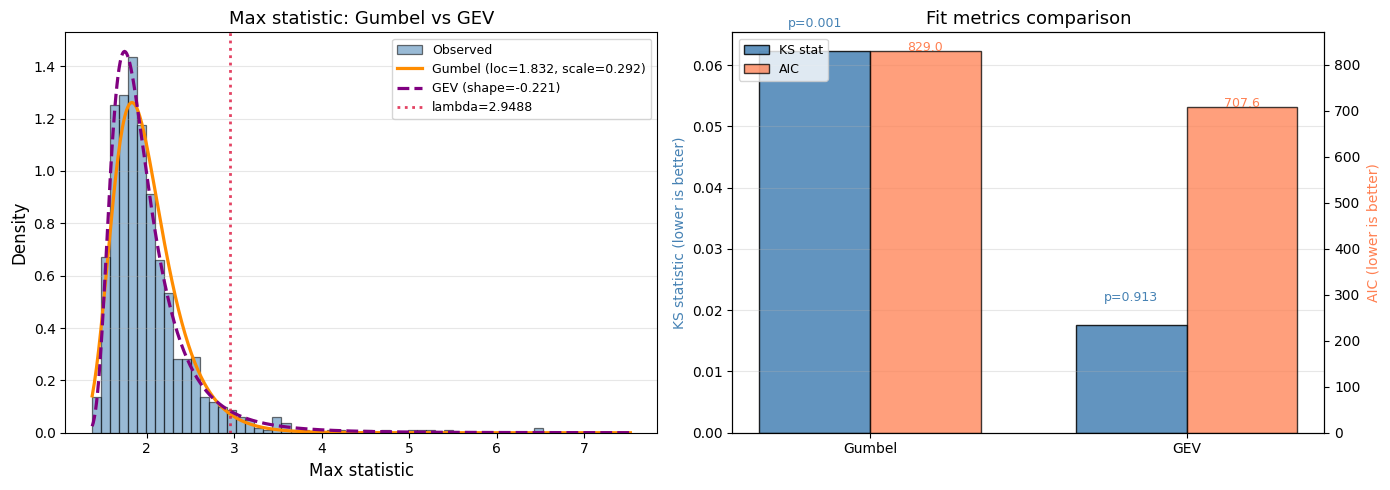


GUMBEL vs GEV COMPARISON
Gumbel: KS=0.062249, p=0.000822, AIC=828.98
GEV:    KS=0.017535, p=0.912796, AIC=707.58
Best by KS:  GEV
Best by AIC: GEV
--------------------------------------------------------------
GEV params: shape=-0.221055, loc=1.797778, scale=0.258337
Note: shape near 0 implies GEV is close to Gumbel.


In [44]:
# --- Plot 6: Gumbel vs GEV fit for max statistic ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram (50 bins)
x_range = np.linspace(final_max_stats.min(), final_max_stats.max() + 1.0, 500)
axes[0].hist(
    final_max_stats,
    bins=50,
    density=True,
    color="steelblue",
    alpha=0.55,
    edgecolor="black",
    linewidth=0.9,
    label="Observed",
)

# Fit Gumbel (GEV with xi = 0)
loc_g, scale_g = stats.gumbel_r.fit(final_max_stats)
pdf_g = stats.gumbel_r.pdf(x_range, loc=loc_g, scale=scale_g)

# Fit full GEV
shape_gev, loc_gev, scale_gev = stats.genextreme.fit(final_max_stats)
pdf_gev = stats.genextreme.pdf(x_range, shape_gev, loc=loc_gev, scale=scale_gev)

axes[0].plot(
    x_range,
    pdf_g,
    color="darkorange",
    linewidth=2.3,
    label=f"Gumbel (loc={loc_g:.3f}, scale={scale_g:.3f})",
)
axes[0].plot(
    x_range,
    pdf_gev,
    color="purple",
    linewidth=2.3,
    linestyle="--",
    label=f"GEV (shape={shape_gev:.3f})",
)

axes[0].axvline(lambda_far, color="crimson", linestyle=":", linewidth=2.0, alpha=0.8, label=f"lambda={lambda_far:.4f}")
axes[0].set_title("Max statistic: Gumbel vs GEV", fontsize=13)
axes[0].set_xlabel("Max statistic", fontsize=12)
axes[0].set_ylabel("Density", fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", alpha=0.3)

# Goodness-of-fit metrics
ks_g = stats.kstest(final_max_stats, lambda x: stats.gumbel_r.cdf(x, loc=loc_g, scale=scale_g))
ks_gev = stats.kstest(final_max_stats, lambda x: stats.genextreme.cdf(x, shape_gev, loc=loc_gev, scale=scale_gev))

pdf_vals_g = stats.gumbel_r.pdf(final_max_stats, loc=loc_g, scale=scale_g)
pdf_vals_gev = stats.genextreme.pdf(final_max_stats, shape_gev, loc=loc_gev, scale=scale_gev)
ll_g = np.sum(np.log(np.clip(pdf_vals_g, 1e-300, None)))
ll_gev = np.sum(np.log(np.clip(pdf_vals_gev, 1e-300, None)))
aic_g = 2 * 2 - 2 * ll_g      # params: loc, scale
aic_gev = 2 * 3 - 2 * ll_gev  # params: shape, loc, scale

# Bar comparison panel
labels = ["Gumbel", "GEV"]
ks_vals = [ks_g.statistic, ks_gev.statistic]
aic_vals = [aic_g, aic_gev]
x = np.arange(len(labels))
width = 0.35

bars1 = axes[1].bar(x - width / 2, ks_vals, width=width, color="steelblue", alpha=0.85, edgecolor="black", label="KS stat")
ax2 = axes[1].twinx()
bars2 = ax2.bar(x + width / 2, aic_vals, width=width, color="coral", alpha=0.75, edgecolor="black", label="AIC")

axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel("KS statistic (lower is better)", color="steelblue")
ax2.set_ylabel("AIC (lower is better)", color="coral")
axes[1].set_title("Fit metrics comparison", fontsize=13)
axes[1].grid(axis="y", alpha=0.3)

for i, pval in enumerate([ks_g.pvalue, ks_gev.pvalue]):
    axes[1].text(i - width / 2, ks_vals[i] + 0.004, f"p={pval:.3f}", ha="center", fontsize=9, color="steelblue")
for i, val in enumerate(aic_vals):
    ax2.text(i + width / 2, val + 1.0, f"{val:.1f}", ha="center", fontsize=9, color="coral")

h1, l1 = axes[1].get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
axes[1].legend(h1 + h2, l1 + l2, loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

best_ks = "GEV" if ks_gev.statistic < ks_g.statistic else "Gumbel"
best_aic = "GEV" if aic_gev < aic_g else "Gumbel"

print("\n" + "=" * 62)
print("GUMBEL vs GEV COMPARISON")
print("=" * 62)
print(f"Gumbel: KS={ks_g.statistic:.6f}, p={ks_g.pvalue:.6f}, AIC={aic_g:.2f}")
print(f"GEV:    KS={ks_gev.statistic:.6f}, p={ks_gev.pvalue:.6f}, AIC={aic_gev:.2f}")
print(f"Best by KS:  {best_ks}")
print(f"Best by AIC: {best_aic}")
print("-" * 62)
print(f"GEV params: shape={shape_gev:.6f}, loc={loc_gev:.6f}, scale={scale_gev:.6f}")
print("Note: shape near 0 implies GEV is close to Gumbel.")
print("=" * 62)

# OLD GLR SECTION:

## 1. General GLR framework for exponential families

The test is fixed; only MLE computation changes:
$$\Lambda = \ell(\hat\theta_1; \text{pre}) + \ell(\hat\theta_2; \text{post}) - \ell(\hat\theta_0; \text{all}).$$

This notebook first builds general numerical solvers for $\hat\theta$ and then benchmarks exact closed-form implementations (when available) as baselines.

### 1.1 Exponential family definitions

We define two example families: **Gaussian** ($\theta = \mu$, $A(\theta)=\theta^2/2$, $h(y)=y$) and **Bernoulli** ($\theta = \text{logit}(p)$, $A(\theta) = \log(1+e^\theta)$, $h(y)=y$).

For each we provide: $h$, $A$, $\nabla A$, $\nabla^2 A$, the inverse link $(\nabla A)^{-1}$, a log-likelihood function, and a penalty.

In [18]:
# =====================================================================
# Exponential family definitions — Gaussian & Bernoulli
# =====================================================================

# ─── Gaussian (known variance σ²=1) ────────────────────────────────
# Natural parameter θ = μ, h(y) = y, A(θ) = θ²/2

V_GAUSS = 1

@nb.njit
def h_gauss(y):
    return y

@nb.njit
def A_gauss(theta):
    """Log-partition for N(θ,1): A(θ) = θ²/2."""
    return 0.5 * np.dot(theta, theta)

@nb.njit
def grad_A_gauss(theta):
    """∇A(θ) = θ."""
    return theta.copy()

@nb.njit
def hess_A_gauss(theta):
    """∇²A(θ) = I."""
    v = theta.shape[0]
    return np.eye(v)

@nb.njit
def grad_A_inv_gauss(mu):
    """Inverse link for Gaussian: identity."""
    return mu.copy()

@nb.njit
def loglik_gauss(theta, S, n):
    """ℓ(θ) = θᵀS − n·A(θ) for Gaussian."""
    return np.dot(theta, S) - n * A_gauss(theta)

# ─── Bernoulli ─────────────────────────────────────────────────────
# Natural parameter θ = logit(p), h(y) = y, A(θ) = log(1+eθ)

V_BERN = 1

@nb.njit
def h_bern(y):
    """Sufficient statistic for Bernoulli: h(y) = y."""
    return y

@nb.njit
def A_bern(theta):
    """Log-partition for Bernoulli: A(θ) = log(1 + exp(θ))."""
    return np.log(1.0 + np.exp(theta)).sum()

@nb.njit
def grad_A_inv_bern(mu):
    """Inverse link (logit): θ = log(μ/(1−μ))."""
    return np.log(mu / (1.0 - mu))

@nb.njit
def grad_A_bern(theta):
    """∇A = sigmoid(θ)."""
    ee = np.exp(theta)
    return ee / (1.0 + ee)

@nb.njit
def hess_A_bern(theta):
    """∇²A for Bernoulli."""
    ee = np.exp(theta)
    H = np.zeros((1, 1), dtype=np.float64)
    H[0, 0] = (ee / ((1.0 + ee) ** 2)).sum()
    return H

@nb.njit
def loglik_bern(theta, S, n):
    """ℓ(θ) = θᵀS − n·A(θ) for Bernoulli."""
    return np.dot(theta, S) - n * A_bern(theta)

# ─── Penalty functions (same for all MLE methods) ─────────────────

@nb.njit
def penalty_glr_gauss(pos, t, p):
    logt = fastlog(t)
    return math.sqrt(V_GAUSS * logt) + logt

@nb.njit
def penalty_glr_bern(g, t, p):
    logt = fastlog(t)
    return math.sqrt(V_BERN * logt) + logt

print("Exponential family definitions compiled.")

Exponential family definitions compiled.


### 1.2 Exact baselines (for known families only)

These closed-form MLE implementations are included as **reference baselines** for distributions where $(\nabla A)^{-1}$ is explicit:
- **Gaussian:** $\hat\theta = S/n$
- **Bernoulli:** $\hat\theta = \mathrm{logit}(S/n)$

In [7]:
# =====================================================================
# Closed-form MLE — when (∇A)⁻¹ is available analytically
# =====================================================================

EPS = 1e-8  # clamping for boundary cases

# ─── Gaussian: θ̂ = S/n (sample mean = natural parameter) ─────────

@nb.njit
def closed_form_mle_gauss(S, n):
    return S / n

@nb.njit
def f_glr_gauss(sum_pre_j, sum_post_j, pos, t):
    """GLR statistic for Gaussian using closed-form MLE."""
    n1, n2 = pos, t - pos
    if n1 < 2 or n2 < 2:
        return 0.0
    S_all = sum_pre_j + sum_post_j
    theta0 = closed_form_mle_gauss(S_all, t)
    theta1 = closed_form_mle_gauss(sum_pre_j, n1)
    theta2 = closed_form_mle_gauss(sum_post_j, n2)
    ll0 = loglik_gauss(theta0, S_all, t)
    ll1 = loglik_gauss(theta1, sum_pre_j, n1)
    ll2 = loglik_gauss(theta2, sum_post_j, n2)
    return ll1 + ll2 - ll0

# ─── Bernoulli: θ̂ = logit(S/n) ───────────────────────────────────

@nb.njit
def closed_form_mle_bern(S, n):
    """MLE via inverse link: θ̂ = (∇A)⁻¹(S/n) = logit(S/n)."""
    mu = S / n
    for i in range(mu.shape[0]):
        if mu[i] < EPS:
            mu[i] = EPS
        elif mu[i] > 1.0 - EPS:
            mu[i] = 1.0 - EPS
    return grad_A_inv_bern(mu)

@nb.njit
def f_glr_bern(sum_pre_j, sum_post_j, pos, t):
    """GLR statistic for Bernoulli using closed-form MLE."""
    n1, n2 = pos, t - pos
    if n1 < 2 or n2 < 2:
        return 0.0
    S_all = sum_pre_j + sum_post_j
    theta0 = closed_form_mle_bern(S_all, t)
    theta1 = closed_form_mle_bern(sum_pre_j, n1)
    theta2 = closed_form_mle_bern(sum_post_j, n2)
    ll0 = loglik_bern(theta0, S_all, t)
    ll1 = loglik_bern(theta1, sum_pre_j, n1)
    ll2 = loglik_bern(theta2, sum_post_j, n2)
    return ll1 + ll2 - ll0

print("Closed-form MLEs compiled.")

Closed-form MLEs compiled.


### 1.3 General solver candidate A: Newton

Newton solves the score equation $\nabla A(\theta)=S/n$ and is the primary candidate for the default general implementation when Hessians are available and well-conditioned.

In [8]:
# =====================================================================
# Solving the score equation via Newton's method
# =====================================================================
# For v=1: scalar root-finding on A'(θ) = S/n  (fast, no arrays)
# For any v: array-based Newton on ∇A(θ) = S/n  (slower, needs Hessian)

# ─── Scalar A, A', A'' for v=1 Newton ────────────────────────────

# Gaussian
@nb.njit
def A_scalar_gauss(theta):
    return 0.5 * theta * theta

@nb.njit
def A_prime_gauss(theta):
    return theta

@nb.njit
def A_dprime_gauss(theta):
    return 1.0

# Bernoulli
@nb.njit
def A_scalar_bern(theta):
    if theta > 30.0:
        return theta
    if theta < -30.0:
        return 0.0
    return math.log(1.0 + math.exp(theta))

@nb.njit
def A_prime_bern(theta):
    if theta > 30.0:
        return 1.0
    if theta < -30.0:
        return 0.0
    e = math.exp(theta)
    return e / (1.0 + e)

@nb.njit
def A_dprime_bern(theta):
    if abs(theta) > 30.0:
        return 0.0
    e = math.exp(theta)
    s = e / (1.0 + e)
    return s * (1.0 - s)

# ─── Generic scalar Newton MLE ───────────────────────────────────

@nb.njit
def scalar_newton_mle(S_scalar, n, theta_init, A_prime, A_dprime, tol=1e-8, max_iter=20):
    """Scalar Newton to solve A'(θ̂) = S/n.
    Pure scalar arithmetic, zero allocations."""
    theta = theta_init
    target = S_scalar / n
    for _ in range(max_iter):
        ap = A_prime(theta)
        residual = ap - target
        if abs(residual) < tol:
            return theta
        adp = A_dprime(theta)
        if adp < 1e-15:
            return theta
        theta = theta - residual / adp
    return theta

@nb.njit
def scalar_loglik(theta, S_scalar, n, A_scalar):
    """Scalar log-likelihood θ·S − n·A(θ)."""
    return theta * S_scalar - n * A_scalar(theta)

# ─── Gaussian: scalar Newton GLR ─────────────────────────────────

@nb.njit
def f_glr_gauss_scalar_newton(sum_pre_j, sum_post_j, pos, t):
    """GLR with scalar Newton for Gaussian v=1."""
    n1, n2 = pos, t - pos
    if n1 < 2 or n2 < 2:
        return 0.0
    s_pre, s_post = sum_pre_j[0], sum_post_j[0]
    s_all = s_pre + s_post
    th0 = scalar_newton_mle(s_all, t, 0.0, A_prime_gauss, A_dprime_gauss)
    th1 = scalar_newton_mle(s_pre, n1, th0, A_prime_gauss, A_dprime_gauss)
    th2 = scalar_newton_mle(s_post, n2, th0, A_prime_gauss, A_dprime_gauss)
    ll0 = scalar_loglik(th0, s_all, t, A_scalar_gauss)
    ll1 = scalar_loglik(th1, s_pre, n1, A_scalar_gauss)
    ll2 = scalar_loglik(th2, s_post, n2, A_scalar_gauss)
    return ll1 + ll2 - ll0

# ─── Bernoulli: scalar Newton GLR ────────────────────────────────

@nb.njit
def f_glr_bern_scalar_newton(sum_pre_j, sum_post_j, pos, t):
    """GLR with scalar Newton for Bernoulli v=1."""
    n1, n2 = pos, t - pos
    if n1 < 2 or n2 < 2:
        return 0.0
    s_pre, s_post = sum_pre_j[0], sum_post_j[0]
    s_all = s_pre + s_post
    th0 = scalar_newton_mle(s_all, t, 0.0, A_prime_bern, A_dprime_bern)
    th1 = scalar_newton_mle(s_pre, n1, th0, A_prime_bern, A_dprime_bern)
    th2 = scalar_newton_mle(s_post, n2, th0, A_prime_bern, A_dprime_bern)
    ll0 = scalar_loglik(th0, s_all, t, A_scalar_bern)
    ll1 = scalar_loglik(th1, s_pre, n1, A_scalar_bern)
    ll2 = scalar_loglik(th2, s_post, n2, A_scalar_bern)
    return ll1 + ll2 - ll0

# ─── Array-based Newton (slow baseline, any v) ───────────────────
# Uses np.linalg.solve + Hessian.  Included for completeness.

@nb.njit
def newton_mle_gauss(S, n, theta_init, tol=1e-12, max_iter=100):
    """Array-based Newton MLE for Gaussian (slow baseline)."""
    theta = theta_init.copy()
    v = theta.shape[0]
    ridge = 1e-8
    ll_old = loglik_gauss(theta, S, n)
    for _ in range(max_iter):
        grad = S - n * grad_A_gauss(theta)
        max_abs = 0.0
        for i in range(v):
            val = abs(grad[i])
            if val > max_abs:
                max_abs = val
        if max_abs < tol:
            return theta
        HA = hess_A_gauss(theta)
        H = -n * HA
        for i in range(v):
            H[i, i] -= ridge
        step = np.linalg.solve(H, grad)
        step_scale = 1.0
        for _ in range(6):
            theta_new = theta + step_scale * step
            ll_new = loglik_gauss(theta_new, S, n)
            if np.isfinite(ll_new) and ll_new >= ll_old:
                theta = theta_new
                ll_old = ll_new
                break
            step_scale *= 0.5
        else:
            theta = theta + step_scale * step
            ll_old = loglik_gauss(theta, S, n)
    return theta

@nb.njit
def f_glr_gauss_newton(sum_pre_j, sum_post_j, pos, t):
    """GLR with array-based Newton (slow baseline)."""
    n1, n2 = pos, t - pos
    if n1 < 2 or n2 < 2:
        return 0.0
    S_all = sum_pre_j + sum_post_j
    theta_init = np.zeros(sum_pre_j.shape[0])
    theta0 = newton_mle_gauss(S_all, t, theta_init)
    theta1 = newton_mle_gauss(sum_pre_j, n1, theta0)
    theta2 = newton_mle_gauss(sum_post_j, n2, theta0)
    ll0 = loglik_gauss(theta0, S_all, t)
    ll1 = loglik_gauss(theta1, sum_pre_j, n1)
    ll2 = loglik_gauss(theta2, sum_post_j, n2)
    return ll1 + ll2 - ll0

print("Newton solvers compiled.")

Newton solvers compiled.


### 1.4 General solver candidate B: Gradient Descent

Gradient methods need only $(A,\nabla A)$ and provide a robust fallback general solver when Newton is unstable or Hessians are unavailable.

In [ ]:
# =====================================================================
# General-purpose GD MLE for exponential families (any dim θ)
# =====================================================================
# Works with vector θ ∈ ℝᵛ and takes function pointers for the
# log-partition A(θ) and its gradient ∇A(θ).
#
# The GD method needs ONLY (A, grad_A) — no Hessian.

# ─── Gradient Descent with Armijo backtracking (general, any dim) ───

@nb.njit
def gd_mle(S, n, theta_init, A_fn, grad_A_fn, tol=1e-8, max_iter=50):
    """Gradient ascent with Armijo backtracking for array-valued θ.

    Maximizes ℓ(θ) = θᵀS − n·A(θ).
    Gradient: ∇ℓ = S − n·∇A(θ).

    Does not need the Hessian ∇²A — first-order only.

    Parameters
    ----------
    S : np.ndarray, shape (v,)   — sufficient statistic sum
    n : int                       — number of observations
    theta_init : np.ndarray (v,)  — starting point
    A_fn : callable(θ) -> float   — log-partition function
    grad_A_fn : callable(θ) -> ndarray(v,) — gradient of A
    tol : float       — convergence tolerance on ‖∇ℓ‖∞
    max_iter : int    — maximum gradient steps

    Returns
    -------
    theta : np.ndarray (v,) — approximate MLE
    """
    theta = theta_init.copy()
    v = theta.shape[0]
    ll = np.dot(theta, S) - n * A_fn(theta)
    c_armijo = 1e-4

    for _ in range(max_iter):
        grad = S - n * grad_A_fn(theta)

        # Check convergence: ‖grad‖∞ < tol
        max_abs = 0.0
        for i in range(v):
            val = abs(grad[i])
            if val > max_abs:
                max_abs = val
        if max_abs < tol:
            return theta

        grad_sq = np.dot(grad, grad)

        # Backtracking line search (Armijo condition)
        eta = 1.0
        for _ in range(20):
            theta_new = theta + eta * grad
            ll_new = np.dot(theta_new, S) - n * A_fn(theta_new)
            if np.isfinite(ll_new) and ll_new >= ll + c_armijo * eta * grad_sq:
                theta = theta_new
                ll = ll_new
                break
            eta *= 0.5
        else:
            theta = theta + eta * grad
            ll = np.dot(theta, S) - n * A_fn(theta)

    return theta

# ─── Generic GLR f-function builder ─────────────────────────────────
# The _glr_stat helper computes the GLR given any MLE solver and A function.

@nb.njit
def _glr_stat(sum_pre_j, sum_post_j, pos, t, mle_fn, A_fn):
    """Core GLR statistic: ℓ(θ̂₁;seg1) + ℓ(θ̂₂;seg2) − ℓ(θ̂₀;all).
    mle_fn(S, n, theta_init) -> theta_hat  (partial application of optimizer)."""
    n1 = pos
    n2 = t - pos
    if n1 < 2 or n2 < 2:
        return 0.0
    S_all = sum_pre_j + sum_post_j
    v = sum_pre_j.shape[0]
    theta_init = np.zeros(v)

    theta0 = mle_fn(S_all, t, theta_init)
    theta1 = mle_fn(sum_pre_j, n1, theta0)
    theta2 = mle_fn(sum_post_j, n2, theta0)

    ll0 = np.dot(theta0, S_all) - t * A_fn(theta0)
    ll1 = np.dot(theta1, sum_pre_j) - n1 * A_fn(theta1)
    ll2 = np.dot(theta2, sum_post_j) - n2 * A_fn(theta2)
    return ll1 + ll2 - ll0

# =====================================================================
# Gaussian specializations (work for any v = dim(θ))
# h_gauss, A_gauss, grad_A_gauss defined in §2.1
# =====================================================================

@nb.njit
def _gd_mle_gauss(S, n, theta_init):
    return gd_mle(S, n, theta_init, A_gauss, grad_A_gauss)

@nb.njit
def f_glr_gauss_gd(sum_pre_j, sum_post_j, pos, t):
    """GLR with gradient descent for Gaussian (any dimension)."""
    return _glr_stat(sum_pre_j, sum_post_j, pos, t, _gd_mle_gauss, A_gauss)

# =====================================================================
# Bernoulli specializations (v=1, but using array form so it's general)
# =====================================================================

@nb.njit
def A_bern_vec(theta):
    """Log-partition for Bernoulli, takes array θ of shape (v,) with v=1."""
    t = theta[0]
    if t > 30.0:
        return t
    if t < -30.0:
        return 0.0
    return math.log(1.0 + math.exp(t))

@nb.njit
def grad_A_bern_vec(theta):
    """∇A for Bernoulli (sigmoid), returns array of shape (1,)."""
    t = theta[0]
    out = np.empty(1)
    if t > 30.0:
        out[0] = 1.0
    elif t < -30.0:
        out[0] = 0.0
    else:
        e = math.exp(t)
        out[0] = e / (1.0 + e)
    return out

@nb.njit
def _gd_mle_bern(S, n, theta_init):
    return gd_mle(S, n, theta_init, A_bern_vec, grad_A_bern_vec)

@nb.njit
def f_glr_bern_gd(sum_pre_j, sum_post_j, pos, t):
    """GLR with gradient descent for Bernoulli."""
    return _glr_stat(sum_pre_j, sum_post_j, pos, t, _gd_mle_bern, A_bern_vec)

print("General GD MLE compiled (supports any dim θ).")

General GD MLE compiled (supports any dim θ).


### 1.5 General solver candidate C: L-BFGS (reference)

L-BFGS is included as a SciPy/Python-path reference solver for comparison. It is useful for validating optimization quality, but it does not run in the Numba-compiled fast path used by production detector loops.

In [ ]:
# =====================================================================
# L-BFGS reference solver (SciPy / Python path)
# =====================================================================

try:
    from scipy.optimize import minimize
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False


def lbfgs_mle(S, n, theta_init, A_fn, grad_A_fn, max_iter=100):
    """Reference MLE solver using L-BFGS-B (Python path)."""
    S = np.asarray(S, dtype=np.float64)
    theta_init = np.asarray(theta_init, dtype=np.float64)

    def obj(theta):
        return n * A_fn(theta) - float(np.dot(theta, S))

    def grad(theta):
        return n * grad_A_fn(theta) - S

    res = minimize(
        obj,
        theta_init,
        jac=grad,
        method="L-BFGS-B",
        options={"maxiter": max_iter, "ftol": 1e-12},
    )
    if res.success and np.all(np.isfinite(res.x)):
        return res.x
    return theta_init


def _glr_stat_py(sum_pre_j, sum_post_j, pos, t, mle_fn, A_fn):
    n1, n2 = pos, t - pos
    if n1 < 2 or n2 < 2:
        return 0.0

    S_all = sum_pre_j + sum_post_j
    theta_init = np.zeros(sum_pre_j.shape[0], dtype=np.float64)

    theta0 = mle_fn(S_all, t, theta_init)
    theta1 = mle_fn(sum_pre_j, n1, theta0)
    theta2 = mle_fn(sum_post_j, n2, theta0)

    ll0 = np.dot(theta0, S_all) - t * A_fn(theta0)
    ll1 = np.dot(theta1, sum_pre_j) - n1 * A_fn(theta1)
    ll2 = np.dot(theta2, sum_post_j) - n2 * A_fn(theta2)
    return float(ll1 + ll2 - ll0)


def _lbfgs_mle_gauss(S, n, theta_init):
    return lbfgs_mle(S, n, theta_init, A_gauss, grad_A_gauss)


def f_glr_gauss_lbfgs(sum_pre_j, sum_post_j, pos, t):
    return _glr_stat_py(sum_pre_j, sum_post_j, pos, t, _lbfgs_mle_gauss, A_gauss)


def _lbfgs_mle_bern(S, n, theta_init):
    return lbfgs_mle(S, n, theta_init, A_bern_vec, grad_A_bern_vec)


def f_glr_bern_lbfgs(sum_pre_j, sum_post_j, pos, t):
    return _glr_stat_py(sum_pre_j, sum_post_j, pos, t, _lbfgs_mle_bern, A_bern_vec)

print(f"L-BFGS reference ready. SciPy available: {SCIPY_AVAILABLE}")

## 2. Solver benchmarking for general GLR

We now benchmark general solver candidates (Newton, GD, L-BFGS reference) and compare against exact closed-form baselines on known families.

### 2.1 Gaussian: general solvers vs exact baselines

Primary comparison: general GLR solvers (Newton, GD, L-BFGS reference). Baselines: exact GLR closed-form and exact GLR CUSUM form.

In [ ]:
# =====================================================================
# Gaussian (v=1): general solvers first, exact baselines second
# =====================================================================
N_nvg = 200
K_cal_nvg = 5000
K_nvg = 1000
changepoint_nvg = N_nvg // 2

methods_gauss = {}

# 1) General GLR — Newton (primary candidate)
det_tmp = OnlineChangepointDetector(
    p=1, f=f_glr_gauss_scalar_newton, h=h_gauss,
    penalty=penalty_glr_gauss, penalty_constant=10.0,
)
det_tmp.calibrate_false_alarm(alpha=0.05, N=N_nvg, K=K_cal_nvg, null_dist=np.random.normal)
methods_gauss["General GLR (Newton)"] = {
    "f": f_glr_gauss_scalar_newton, "h": h_gauss, "penalty": penalty_glr_gauss,
    "pen_const": det_tmp._state["penalty_constant"],
}

# 2) General GLR — gradient descent
det_tmp = OnlineChangepointDetector(
    p=1, f=f_glr_gauss_gd, h=h_gauss,
    penalty=penalty_glr_gauss, penalty_constant=10.0,
)
det_tmp.calibrate_false_alarm(alpha=0.05, N=N_nvg, K=K_cal_nvg, null_dist=np.random.normal)
methods_gauss["General GLR (GD)"] = {
    "f": f_glr_gauss_gd, "h": h_gauss, "penalty": penalty_glr_gauss,
    "pen_const": det_tmp._state["penalty_constant"],
}

# 3) General GLR — L-BFGS reference (Python path)
if SCIPY_AVAILABLE:
    det_tmp = OnlineChangepointDetector(
        p=1, f=f_glr_gauss_lbfgs, h=h_gauss,
        penalty=penalty_glr_gauss, penalty_constant=10.0,
    )
    det_tmp.calibrate_false_alarm(alpha=0.05, N=N_nvg, K=min(1000, K_cal_nvg), null_dist=np.random.normal)
    methods_gauss["General GLR (L-BFGS ref)"] = {
        "f": f_glr_gauss_lbfgs, "h": h_gauss, "penalty": penalty_glr_gauss,
        "pen_const": det_tmp._state["penalty_constant"],
    }

# 4) Exact GLR baseline — closed-form MLE
det_tmp = OnlineChangepointDetector(
    p=1, f=f_glr_gauss, h=h_gauss,
    penalty=penalty_glr_gauss, penalty_constant=10.0,
)
det_tmp.calibrate_false_alarm(alpha=0.05, N=N_nvg, K=K_cal_nvg, null_dist=np.random.normal)
methods_gauss["Exact GLR baseline (closed-form)"] = {
    "f": f_glr_gauss, "h": h_gauss, "penalty": penalty_glr_gauss,
    "pen_const": det_tmp._state["penalty_constant"],
}

# 5) Exact GLR baseline — CUSUM form
det_tmp = make_univariate_mean_change_detector()
det_tmp.calibrate_false_alarm(alpha=0.05, N=N_nvg, K=K_cal_nvg, null_dist=np.random.normal)
methods_gauss["Exact GLR baseline (CUSUM form)"] = {
    "pen_const": det_tmp._state["penalty_constant"], "make_det": "cusum",
}

print("Gaussian (v=1) — calibrated thresholds:")
for name, m in methods_gauss.items():
    print(f"  {name:<35s} λ = {m['pen_const']:.3f}")

# Generate test data: N(0,1) → N(2,1)
xs_nvg = draw_samples(
    K=K_nvg, N=N_nvg, p=1, seed=42,
    pre_change_dist=np.random.normal,
    pre_change_kwargs={"loc": 0, "scale": 1, "size": (1,)},
    post_change_dist=np.random.normal,
    post_change_kwargs={"loc": 2, "scale": 1, "size": (1,)},
    changepoint_loc=changepoint_nvg,
)

# --- Run all methods and time them ---
results_gauss = {}
for name, m in methods_gauss.items():
    dt = np.ones(K_nvg, dtype=np.int64) * N_nvg
    t0 = perf_counter()
    for k in range(K_nvg):
        if m.get("make_det") == "cusum":
            d = make_univariate_mean_change_detector(penalty_constant=m["pen_const"])
        else:
            d = OnlineChangepointDetector(
                p=1, f=m["f"], h=m["h"],
                penalty=m["penalty"], penalty_constant=m["pen_const"],
            )
        for i in range(N_nvg):
            d.update(xs_nvg[k, i])
            if d.alarm:
                dt[k] = i + 1
                break
    elapsed = perf_counter() - t0
    results_gauss[name] = {"dt": dt, "time": elapsed}

print(f"\n{'Method':<35} {'Avg delay':>10} {'Detected':>10} {'Time (s)':>10}")
print("-" * 68)
for name, r in results_gauss.items():
    delay = np.mean(r["dt"]) - changepoint_nvg
    det_rate = np.mean(r["dt"] < N_nvg)
    print(f"{name:<35} {delay:>10.1f} {det_rate:>10.3f} {r['time']:>10.2f}")

Gaussian (v=1) — calibrated thresholds:
  Closed-form GLR           λ = 1.410
  Scalar Newton GLR         λ = 1.410
  Gradient Descent GLR      λ = 1.410
  Built-in CUSUM            λ = 2.963

Method                     Avg delay   Detected   Time (s)
----------------------------------------------------------
Closed-form GLR                  1.8      1.000       2.08
Scalar Newton GLR                1.8      1.000       1.86
Gradient Descent GLR             1.8      1.000      26.12
Built-in CUSUM                   3.1      1.000       1.84


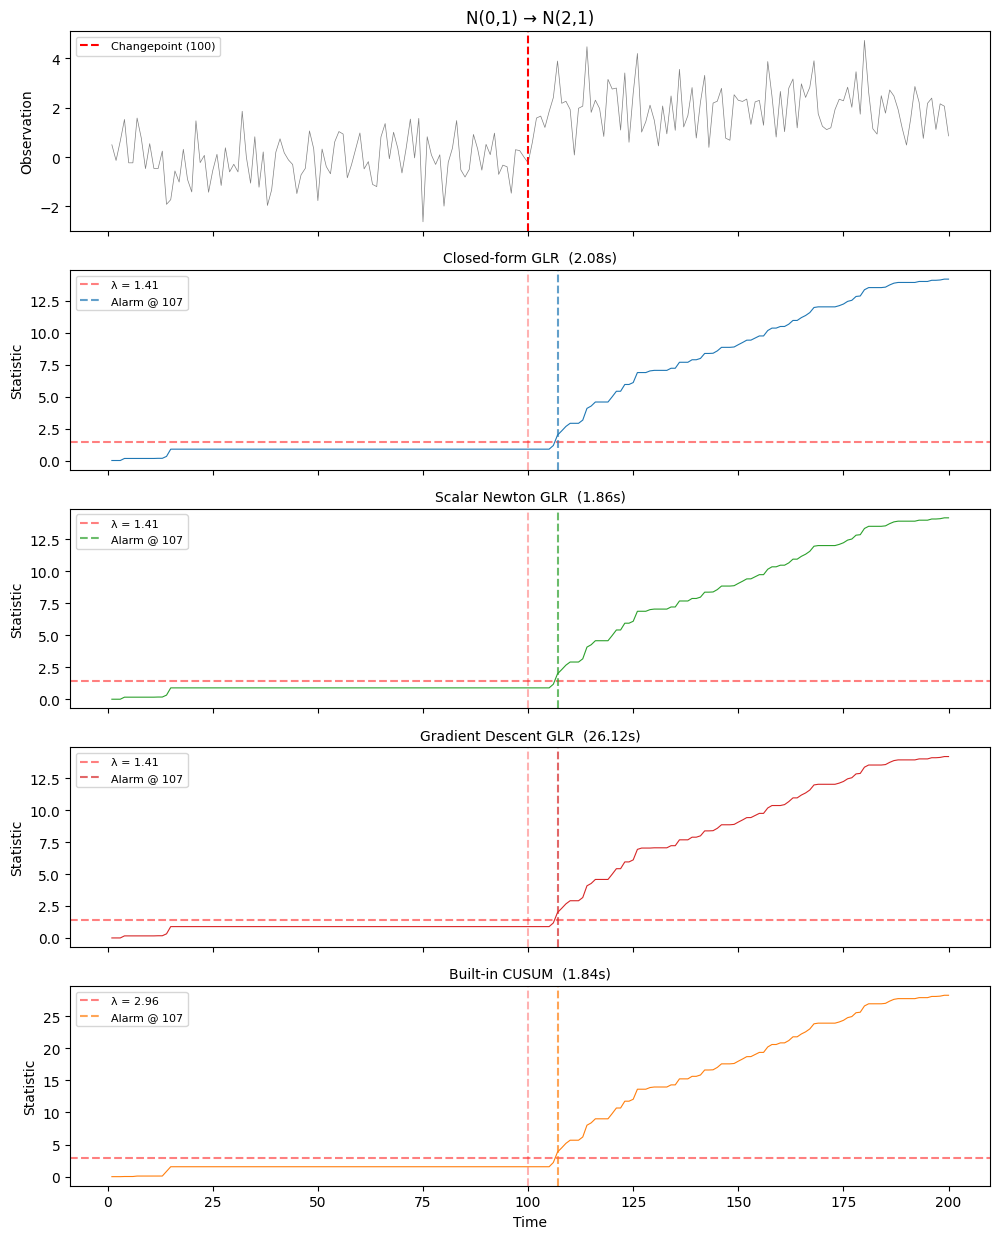

In [ ]:
# Visualize all methods on a single stream
stream = xs_nvg[0]
method_names_g = list(methods_gauss.keys())
n_methods = len(method_names_g)

color_map_g = {
    "General GLR (Newton)": "tab:green",
    "General GLR (GD)": "tab:red",
    "General GLR (L-BFGS ref)": "tab:purple",
    "Exact GLR baseline (closed-form)": "tab:blue",
    "Exact GLR baseline (CUSUM form)": "tab:orange",
}

fig, axes = plt.subplots(n_methods + 1, 1,
                         figsize=(10, 2.5 * (n_methods + 1)), sharex=True)

# Top panel: data
axes[0].plot(np.arange(1, N_nvg + 1), stream[:, 0], linewidth=0.5, color="gray")
axes[0].axvline(changepoint_nvg, color="red", ls="--",
                label=f"Changepoint ({changepoint_nvg})")
axes[0].set_ylabel("Observation")
axes[0].legend(fontsize=8)
axes[0].set_title("N(0,1) → N(2,1)")

for idx, name in enumerate(method_names_g):
    m = methods_gauss[name]
    if m.get("make_det") == "cusum":
        d = make_univariate_mean_change_detector(penalty_constant=m["pen_const"])
    else:
        d = OnlineChangepointDetector(
            p=1, f=m["f"], h=m["h"],
            penalty=m["penalty"], penalty_constant=m["pen_const"],
        )
    st = np.zeros(N_nvg)
    alarm = None
    for i in range(N_nvg):
        d.update(stream[i])
        st[i] = d.max_statistic
        if d.alarm and alarm is None:
            alarm = i + 1
    color = color_map_g.get(name, "gray")
    ax = axes[idx + 1]
    ax.plot(np.arange(1, N_nvg + 1), np.maximum(st, 1e-6),
            linewidth=0.8, color=color)
    ax.axhline(m["pen_const"], color="red", ls="--", alpha=0.5,
               label=f"λ = {m['pen_const']:.2f}")
    ax.axvline(changepoint_nvg, color="red", ls="--", alpha=0.3)
    if alarm:
        ax.axvline(alarm, color=color, ls="--", alpha=0.7,
                   label=f"Alarm @ {alarm}")
    ax.set_ylabel("Statistic")
    ax.set_title(f"{name}  ({results_gauss[name]['time']:.2f}s)", fontsize=10)
    ax.legend(fontsize=8)

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

### 2.2 Bernoulli: general solvers vs exact baseline

In [ ]:
# =====================================================================
# Bernoulli: general solvers first, exact baseline second
# =====================================================================
N_nvb = 200
K_cal_nvb = 5000
K_nvb = 1000
changepoint_nvb = N_nvb // 2

methods_bern = {}

# 1) General GLR — Newton (primary candidate)
det_tmp = OnlineChangepointDetector(
    p=1, f=f_glr_bern_scalar_newton, h=h_bern,
    penalty=penalty_glr_bern, penalty_constant=10.0,
)
det_tmp.calibrate_false_alarm(
    alpha=0.05, N=N_nvb, K=K_cal_nvb,
    null_dist=np.random.binomial,
    null_kwargs={"n": 1, "p": 0.5, "size": (1,)},
)
methods_bern["General GLR (Newton)"] = {
    "f": f_glr_bern_scalar_newton, "h": h_bern, "penalty": penalty_glr_bern,
    "pen_const": det_tmp._state["penalty_constant"],
}

# 2) General GLR — gradient descent
det_tmp = OnlineChangepointDetector(
    p=1, f=f_glr_bern_gd, h=h_bern,
    penalty=penalty_glr_bern, penalty_constant=10.0,
)
det_tmp.calibrate_false_alarm(
    alpha=0.05, N=N_nvb, K=K_cal_nvb,
    null_dist=np.random.binomial,
    null_kwargs={"n": 1, "p": 0.5, "size": (1,)},
)
methods_bern["General GLR (GD)"] = {
    "f": f_glr_bern_gd, "h": h_bern, "penalty": penalty_glr_bern,
    "pen_const": det_tmp._state["penalty_constant"],
}

# 3) General GLR — L-BFGS reference (Python path)
if SCIPY_AVAILABLE:
    det_tmp = OnlineChangepointDetector(
        p=1, f=f_glr_bern_lbfgs, h=h_bern,
        penalty=penalty_glr_bern, penalty_constant=10.0,
    )
    det_tmp.calibrate_false_alarm(
        alpha=0.05, N=N_nvb, K=min(1000, K_cal_nvb),
        null_dist=np.random.binomial,
        null_kwargs={"n": 1, "p": 0.5, "size": (1,)},
    )
    methods_bern["General GLR (L-BFGS ref)"] = {
        "f": f_glr_bern_lbfgs, "h": h_bern, "penalty": penalty_glr_bern,
        "pen_const": det_tmp._state["penalty_constant"],
    }

# 4) Exact GLR baseline — closed-form MLE
det_tmp = OnlineChangepointDetector(
    p=1, f=f_glr_bern, h=h_bern,
    penalty=penalty_glr_bern, penalty_constant=10.0,
)
det_tmp.calibrate_false_alarm(
    alpha=0.05, N=N_nvb, K=K_cal_nvb,
    null_dist=np.random.binomial,
    null_kwargs={"n": 1, "p": 0.5, "size": (1,)},
)
methods_bern["Exact GLR baseline (closed-form)"] = {
    "f": f_glr_bern, "h": h_bern, "penalty": penalty_glr_bern,
    "pen_const": det_tmp._state["penalty_constant"],
}

print("Bernoulli — calibrated thresholds:")
for name, m in methods_bern.items():
    print(f"  {name:<35s} λ = {m['pen_const']:.3f}")

# Generate test data: Bernoulli(0.3) → Bernoulli(0.7)
xs_nvb = draw_samples(
    K=K_nvb, N=N_nvb, p=1, seed=42,
    pre_change_dist=np.random.binomial,
    pre_change_kwargs={"n": 1, "p": 0.3, "size": (1,)},
    post_change_dist=np.random.binomial,
    post_change_kwargs={"n": 1, "p": 0.7, "size": (1,)},
    changepoint_loc=changepoint_nvb,
)

# --- Run all methods and time them ---
results_bern = {}
for name, m in methods_bern.items():
    dt = np.ones(K_nvb, dtype=np.int64) * N_nvb
    t0 = perf_counter()
    for k in range(K_nvb):
        d = OnlineChangepointDetector(
            p=1, f=m["f"], h=m["h"],
            penalty=m["penalty"], penalty_constant=m["pen_const"],
        )
        for i in range(N_nvb):
            d.update(xs_nvb[k, i])
            if d.alarm:
                dt[k] = i + 1
                break
    elapsed = perf_counter() - t0
    results_bern[name] = {"dt": dt, "time": elapsed}

print(f"\n{'Method':<35} {'Avg delay':>10} {'Detected':>10} {'Time (s)':>10}")
print("-" * 68)
for name, r in results_bern.items():
    delay = np.mean(r["dt"]) - changepoint_nvb
    det_rate = np.mean(r["dt"] < N_nvb)
    print(f"{name:<35} {delay:>10.1f} {det_rate:>10.3f} {r['time']:>10.2f}")

Bernoulli — calibrated thresholds:
  Scalar Newton GLR         λ = 1.431
  Gradient Descent GLR      λ = 1.403

Method                     Avg delay   Detected   Time (s)
----------------------------------------------------------
Scalar Newton GLR               45.1      0.889       3.11
Gradient Descent GLR            43.0      0.901       6.55


### 2.2b Exact baseline reference: Gaussian CUSUM form

This section is an exact baseline only. For Gaussian mean change, CUSUM is algebraically equivalent to the exact GLR after closed-form simplification.

In [ ]:
# Exact baseline CUSUM implementation (Gaussian mean-change)

@nb.njit
def h_cusum(y):
    return y


@nb.njit
def f_cusum(sum_pre_j, sum_post_j, g, t):
    res = math.sqrt(1.0 * g / (t * (t - g))) * sum_pre_j
    res = res - math.sqrt(1.0 * (t - g) / t / g) * sum_post_j
    return np.sum(res * res)


@nb.njit
def penalty_cusum(g, t, p):
    logg = fastlog(t / 0.05)
    rr = math.sqrt(p * logg) + logg
    return rr


# Quick baseline check
detector_cusum = OnlineChangepointDetector(
    p=1, f=f_cusum, h=h_cusum, penalty=penalty_cusum, penalty_constant=10
)
detector_cusum.calibrate_false_alarm(alpha=0.05, N=1000, K=1000, null_dist=np.random.normal)

N_cus = 1000
changepoint_cus = 500
K_cus = 1000

xs_cus = draw_samples(
    K=K_cus, N=N_cus, p=1, seed=42,
    pre_change_dist=np.random.normal,
    pre_change_kwargs={"loc": 0, "scale": 1, "size": (1,)},
    post_change_dist=np.random.normal,
    post_change_kwargs={"loc": 2, "scale": 1, "size": (1,)},
    changepoint_loc=changepoint_cus,
)

pen_const_cus = detector_cusum._state["penalty_constant"]
detect_times_cus = np.ones(K_cus, dtype=np.int64) * N_cus
for k in range(K_cus):
    det = OnlineChangepointDetector(
        p=1, f=f_cusum, h=h_cusum,
        penalty=penalty_cusum, penalty_constant=pen_const_cus,
    )
    for i in range(N_cus):
        det.update(xs_cus[k, i])
        if det.alarm:
            detect_times_cus[k] = i + 1
            break

print(f"CUSUM baseline — Average detection delay: {np.mean(detect_times_cus) - changepoint_cus:.1f}")
print(f"CUSUM baseline — Proportion detected: {np.mean(detect_times_cus < N_cus):.3f}")

### 2.3 Detection delay vs change magnitude

In [ ]:
# =====================================================================
# Gaussian: Detection delay vs change magnitude (general + baselines)
# =====================================================================
phis_gauss = np.linspace(0, 6, 10)
K_sw = 1000
N_sw = 200
cp_sw = N_sw // 2

# Store detection times: shape (n_methods, n_phis, K)
method_names_g = list(methods_gauss.keys())
dd_gauss = {name: np.ones((len(phis_gauss), K_sw)) * N_sw for name in method_names_g}

for j, phi in enumerate(phis_gauss):
    xs_sw = draw_samples(
        K=K_sw, N=N_sw, p=1, seed=1234,
        pre_change_dist=np.random.normal,
        pre_change_kwargs={"loc": 0, "scale": 1, "size": (1,)},
        post_change_dist=np.random.normal,
        post_change_kwargs={"loc": phi, "scale": 1, "size": (1,)},
        changepoint_loc=cp_sw,
    )
    for k in range(K_sw):
        for name, m in methods_gauss.items():
            if m.get("make_det") == "cusum":
                d = make_univariate_mean_change_detector(penalty_constant=m["pen_const"])
            else:
                d = OnlineChangepointDetector(
                    p=1, f=m["f"], h=m["h"],
                    penalty=m["penalty"], penalty_constant=m["pen_const"],
                )
            for i in range(N_sw):
                d.update(xs_sw[k, i])
                if d.alarm:
                    dd_gauss[name][j, k] = i + 1
                    break

# Print false alarm rates at φ=0
print("Gaussian — False alarm rates at φ=0:")
for name in method_names_g:
    far = np.mean(dd_gauss[name][0] < N_sw)
    print(f"  {name:<35s} {far:.3f}")

# =====================================================================
# Bernoulli: Detection delay vs change magnitude (general + baseline)
# =====================================================================
# Parameterize by probabilities: pre=0.3, post sweeps from 0.3 to 0.9
probs_bern = np.linspace(0.3, 0.9, 10)
dd_bern = {name: np.ones((len(probs_bern), K_sw)) * N_sw for name in methods_bern}

for j, p_post in enumerate(probs_bern):
    xs_sw_b = draw_samples(
        K=K_sw, N=N_sw, p=1, seed=1234,
        pre_change_dist=np.random.binomial,
        pre_change_kwargs={"n": 1, "p": 0.3, "size": (1,)},
        post_change_dist=np.random.binomial,
        post_change_kwargs={"n": 1, "p": p_post, "size": (1,)},
        changepoint_loc=cp_sw,
    )
    for k in range(K_sw):
        for name, m in methods_bern.items():
            d = OnlineChangepointDetector(
                p=1, f=m["f"], h=m["h"],
                penalty=m["penalty"], penalty_constant=m["pen_const"],
            )
            for i in range(N_sw):
                d.update(xs_sw_b[k, i])
                if d.alarm:
                    dd_bern[name][j, k] = i + 1
                    break

print("\nBernoulli — False alarm rates at p_post=0.3 (no change):")
for name in methods_bern:
    far = np.mean(dd_bern[name][0] < N_sw)
    print(f"  {name:<35s} {far:.3f}")

Gaussian — False alarm rates at φ=0:
  Closed-form GLR           0.056
  Scalar Newton GLR         0.056
  Gradient Descent GLR      0.054
  Built-in CUSUM            0.046

Bernoulli — False alarm rates at p_post=0.3 (no change):
  Scalar Newton GLR         0.029
  Gradient Descent GLR      0.030


In [ ]:
# =====================================================================
# Plot 1: Detection delay vs change magnitude
# =====================================================================
markers = {
    "General GLR (Newton)":              "s--",
    "General GLR (GD)":                  "D-.",
    "General GLR (L-BFGS ref)":          "P-",
    "Exact GLR baseline (closed-form)":  "o-",
    "Exact GLR baseline (CUSUM form)":   "^:",
}
colors = {
    "General GLR (Newton)":              "tab:green",
    "General GLR (GD)":                  "tab:red",
    "General GLR (L-BFGS ref)":          "tab:purple",
    "Exact GLR baseline (closed-form)":  "tab:blue",
    "Exact GLR baseline (CUSUM form)":   "tab:orange",
}

# Bernoulli uses the same general/baseline style
colors_b = {
    "General GLR (Newton)":              "tab:green",
    "General GLR (GD)":                  "tab:red",
    "General GLR (L-BFGS ref)":          "tab:purple",
    "Exact GLR baseline (closed-form)":  "tab:blue",
}
markers_b = {
    "General GLR (Newton)":              "s--",
    "General GLR (GD)":                  "D-.",
    "General GLR (L-BFGS ref)":          "P-",
    "Exact GLR baseline (closed-form)":  "o-",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Gaussian
ax = axes[0]
for name in method_names_g:
    avg_dd = np.mean(dd_gauss[name], axis=1) - cp_sw
    ax.plot(phis_gauss, avg_dd, markers.get(name, "o-"),
            color=colors.get(name, None), label=name, linewidth=1.5)
ax.set_xlabel("Mean change magnitude φ")
ax.set_ylabel("Average detection delay")
ax.set_title("Gaussian N(0,1) → N(φ,1)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right: Bernoulli
ax = axes[1]
for name in methods_bern:
    avg_dd = np.mean(dd_bern[name], axis=1) - cp_sw
    ax.plot(probs_bern, avg_dd, markers_b.get(name, "o-"),
            color=colors_b.get(name, None), label=name, linewidth=1.5)
ax.set_xlabel("Post-change probability p")
ax.set_ylabel("Average detection delay")
ax.set_title("Bernoulli Bern(0.3) → Bern(p)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

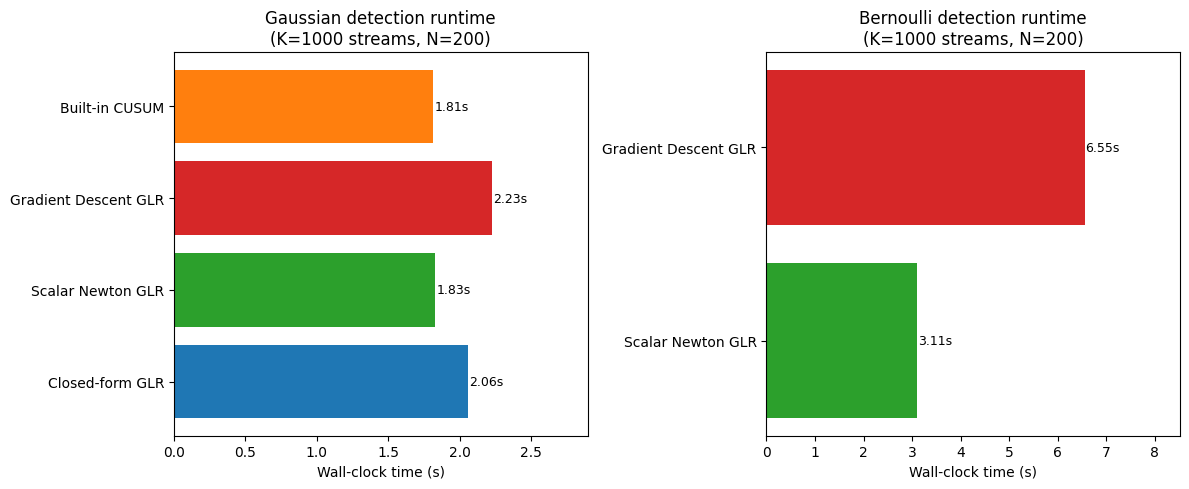


SUMMARY: Newton vs Gradient Descent for GLR Optimization

Gaussian N(0,1) → N(2,1):
  Method                     Avg delay   Detected       Time    Speedup
  --------------------------------------------------------------------
  Closed-form GLR                  1.8      1.000      2.06s      1.08x
  Scalar Newton GLR                1.8      1.000      1.83s      1.22x
  Gradient Descent GLR             1.8      1.000      2.23s      1.00x
  Built-in CUSUM                   3.1      1.000      1.81s      1.23x

Bernoulli Bern(0.3) → Bern(0.7):
  Method                     Avg delay   Detected       Time    Speedup
  --------------------------------------------------------------------
  Scalar Newton GLR               45.1      0.889      3.11s      2.11x
  Gradient Descent GLR            43.0      0.901      6.55s      1.00x


In [ ]:
# =====================================================================
# Plot 2: Wall-clock timing comparison (bar chart)
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Gaussian timing
ax = axes[0]
names_g = list(results_gauss.keys())
times_g = [results_gauss[n]["time"] for n in names_g]
bars = ax.barh(names_g, times_g, color=[colors.get(n, "gray") for n in names_g])
ax.set_xlabel("Wall-clock time (s)")
ax.set_title(f"Gaussian detection runtime\n(K={K_nvg} streams, N={N_nvg})")
for bar, t in zip(bars, times_g):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{t:.2f}s", va="center", fontsize=9)
ax.set_xlim(0, max(times_g) * 1.3)

# Right: Bernoulli timing
ax = axes[1]
names_b = list(results_bern.keys())
times_b = [results_bern[n]["time"] for n in names_b]
bars = ax.barh(names_b, times_b, color=[colors_b.get(n, "gray") for n in names_b])
ax.set_xlabel("Wall-clock time (s)")
ax.set_title(f"Bernoulli detection runtime\n(K={K_nvb} streams, N={N_nvb})")
for bar, t in zip(bars, times_b):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{t:.2f}s", va="center", fontsize=9)
ax.set_xlim(0, max(times_b) * 1.3)

plt.tight_layout()
plt.show()

# --- Summary statistics ---
print("\n" + "=" * 70)
print("SUMMARY: General GLR solvers vs exact baselines")
print("=" * 70)

print("\nGaussian N(0,1) → N(2,1):")
print(f"  {'Method':<35} {'Avg delay':>10} {'Detected':>10} {'Time':>10} {'Speedup':>10}")
print("  " + "-" * 78)
ref_time_g = results_gauss.get("General GLR (Newton)", {}).get("time", 1.0)
for name, r in results_gauss.items():
    delay = np.mean(r["dt"]) - changepoint_nvg
    det_rate = np.mean(r["dt"] < N_nvg)
    speedup = ref_time_g / r["time"] if r["time"] > 0 else float("inf")
    print(f"  {name:<35} {delay:>10.1f} {det_rate:>10.3f} {r['time']:>9.2f}s {speedup:>9.2f}x")

print(f"\nBernoulli Bern(0.3) → Bern(0.7):")
print(f"  {'Method':<35} {'Avg delay':>10} {'Detected':>10} {'Time':>10} {'Speedup':>10}")
print("  " + "-" * 78)
ref_time_b = results_bern.get("General GLR (Newton)", {}).get("time", 1.0)
for name, r in results_bern.items():
    delay = np.mean(r["dt"]) - changepoint_nvb
    det_rate = np.mean(r["dt"] < N_nvb)
    speedup = ref_time_b / r["time"] if r["time"] > 0 else float("inf")
    print(f"  {name:<35} {delay:>10.1f} {det_rate:>10.3f} {r['time']:>9.2f}s {speedup:>9.2f}x")

print("\nConclusion candidate: Newton is the default general solver; GD is the robust fallback; L-BFGS is a Python-path reference.")

### 2.4 Multivariate Gaussian: general solver vs exact baseline

In multivariate settings, we benchmark the general solver against a known exact built-in baseline.

In [ ]:
# =====================================================================
# Multivariate Gaussian (v=5): exact GLR (built-in) vs general GLR (GD)
# =====================================================================
# θ ∈ ℝ⁵, A(θ) = ‖θ‖²/2, h(y) = y, known covariance = I₅
# Only GD (general GLR) and the built-in closed-form (exact GLR) can handle this.

P_MV = 5  # dimension of the observation / natural parameter
N_mv = 200
K_cal_mv = 5000
K_mv = 1000
changepoint_mv = N_mv // 2

# Penalty for v-dimensional Gaussian
@nb.njit
def penalty_glr_gauss_mv(g, t, p):
    logt = fastlog(t)
    return math.sqrt(p * logt) + logt

methods_mv = {}

# 1) General GLR — gradient descent (works for any v)
det_tmp = OnlineChangepointDetector(
    p=P_MV, f=f_glr_gauss_gd, h=h_gauss,
    penalty=penalty_glr_gauss_mv, penalty_constant=10.0,
)
det_tmp.calibrate_false_alarm(
    alpha=0.05, N=N_mv, K=K_cal_mv, null_dist=np.random.normal,
)
methods_mv["General GLR (GD)"] = {
    "f": f_glr_gauss_gd, "h": h_gauss, "penalty": penalty_glr_gauss_mv,
    "pen_const": det_tmp._state["penalty_constant"],
}

# 2) Exact GLR — built-in multivariate mean change detector (closed-form)
det_tmp = make_multivariate_mean_change_detector(p=P_MV)
det_tmp.calibrate_false_alarm(
    alpha=0.05, N=N_mv, K=K_cal_mv, null_dist=np.random.normal,
)
methods_mv["Exact GLR (built-in)"] = {
    "pen_const": det_tmp._state["penalty_constant"], "make_det": "builtin_mv",
}

print(f"Multivariate Gaussian (v={P_MV}) — calibrated thresholds:")
for name, m in methods_mv.items():
    print(f"  {name:<30s} λ = {m['pen_const']:.3f}")

# Generate test data: N(0,I₅) → N(μ₁,I₅) where μ₁ = (1,1,0,...,0)
mu_post = np.zeros(P_MV)
mu_post[0] = 1.0
mu_post[1] = 1.0

xs_mv = draw_samples(
    K=K_mv, N=N_mv, p=P_MV, seed=42,
    pre_change_dist=np.random.normal,
    pre_change_kwargs={"loc": np.zeros(P_MV), "scale": 1, "size": (P_MV,)},
    post_change_dist=np.random.normal,
    post_change_kwargs={"loc": mu_post, "scale": 1, "size": (P_MV,)},
    changepoint_loc=changepoint_mv,
)

# --- Run all methods and time them ---
results_mv = {}
for name, m in methods_mv.items():
    dt = np.ones(K_mv, dtype=np.int64) * N_mv
    t0 = perf_counter()
    for k in range(K_mv):
        if m.get("make_det") == "builtin_mv":
            d = make_multivariate_mean_change_detector(p=P_MV, penalty_constant=m["pen_const"])
        else:
            d = OnlineChangepointDetector(
                p=P_MV, f=m["f"], h=m["h"],
                penalty=m["penalty"], penalty_constant=m["pen_const"],
            )
        for i in range(N_mv):
            d.update(xs_mv[k, i])
            if d.alarm:
                dt[k] = i + 1
                break
    elapsed = perf_counter() - t0
    results_mv[name] = {"dt": dt, "time": elapsed}

print(f"\n{'Method':<30} {'Avg delay':>10} {'Detected':>10} {'Time (s)':>10}")
print("-" * 63)
for name, r in results_mv.items():
    delay = np.mean(r["dt"]) - changepoint_mv
    det_rate = np.mean(r["dt"] < N_mv)
    print(f"{name:<30} {delay:>10.1f} {det_rate:>10.3f} {r['time']:>10.2f}")

In [ ]:
# =====================================================================
# Multivariate: Detection delay vs change magnitude + timing
# =====================================================================
# Sweep ‖μ_post‖ from 0 to 4 (change in first two components)
magnitudes_mv = np.linspace(0, 4, 9)
dd_mv = {name: np.ones((len(magnitudes_mv), K_sw)) * N_mv for name in methods_mv}

for j, mag in enumerate(magnitudes_mv):
    mu_post_j = np.zeros(P_MV)
    mu_post_j[0] = mag / math.sqrt(2)
    mu_post_j[1] = mag / math.sqrt(2)

    xs_sw_mv = draw_samples(
        K=K_sw, N=N_mv, p=P_MV, seed=1234,
        pre_change_dist=np.random.normal,
        pre_change_kwargs={"loc": np.zeros(P_MV), "scale": 1, "size": (P_MV,)},
        post_change_dist=np.random.normal,
        post_change_kwargs={"loc": mu_post_j, "scale": 1, "size": (P_MV,)},
        changepoint_loc=changepoint_mv,
    )
    for k in range(K_sw):
        for name, m in methods_mv.items():
            if m.get("make_det") == "builtin_mv":
                d = make_multivariate_mean_change_detector(p=P_MV, penalty_constant=m["pen_const"])
            else:
                d = OnlineChangepointDetector(
                    p=P_MV, f=m["f"], h=m["h"],
                    penalty=m["penalty"], penalty_constant=m["pen_const"],
                )
            for i in range(N_mv):
                d.update(xs_sw_mv[k, i])
                if d.alarm:
                    dd_mv[name][j, k] = i + 1
                    break

# --- Plots ---
colors_mv = {
    "General GLR (GD)":    "tab:red",
    "Exact GLR (built-in)": "tab:blue",
}
markers_mv = {
    "General GLR (GD)":    "D-.",
    "Exact GLR (built-in)": "o-",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Detection delay vs magnitude
ax = axes[0]
for name in methods_mv:
    avg_dd = np.mean(dd_mv[name], axis=1) - changepoint_mv
    ax.plot(magnitudes_mv, avg_dd, markers_mv.get(name, "o-"),
            color=colors_mv.get(name, None), label=name, linewidth=1.5)
ax.set_xlabel("‖μ_post‖ (change magnitude)")
ax.set_ylabel("Average detection delay")
ax.set_title(f"Multivariate Gaussian (v={P_MV}), N={N_mv}")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right: Timing bar chart
ax = axes[1]
names_mv = list(results_mv.keys())
times_mv = [results_mv[n]["time"] for n in names_mv]
bars = ax.barh(names_mv, times_mv, color=[colors_mv.get(n, "gray") for n in names_mv])
ax.set_xlabel("Wall-clock time (s)")
ax.set_title(f"Multivariate detection runtime\n(v={P_MV}, K={K_mv}, N={N_mv})")
for bar, t_val in zip(bars, times_mv):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{t_val:.2f}s", va="center", fontsize=9)
ax.set_xlim(0, max(times_mv) * 1.3)

plt.tight_layout()
plt.show()

# Summary
print(f"\nMultivariate Gaussian (v={P_MV}), N(0,I) → N(μ,I) with ‖μ‖={np.linalg.norm(mu_post):.1f}:")
print(f"  {'Method':<30} {'Avg delay':>10} {'Detected':>10} {'Time':>10}")
print("  " + "-" * 63)
for name, r in results_mv.items():
    delay = np.mean(r["dt"]) - changepoint_mv
    det_rate = np.mean(r["dt"] < N_mv)
    print(f"  {name:<30} {delay:>10.1f} {det_rate:>10.3f} {r['time']:>9.2f}s")